In [9]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from scipy.stats import pearsonr, zscore
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# External configs (assumes these are in your config.py and vizman)
from vizman import viz
from config import COLOR_SCHEME, LABEL_MAP # PROPERTY_NAMES, CATEGORY_COLOURS, CATEGORY_ORDER, remaining_categories, SELECTED_PROPERTIES_NAMES 
from analysis_08_cluster_contributions import CLUSTERS 
from analysis_08_cluster_contributions import CLUSTER_COLORS as CATEGORY_COLOURS
from config import MERGED_PROPERTIES_NAMES as SELECTED_PROPERTIES_NAMES
from utils import get_combined_colors
from config_pca_parameter_selection import remaining_categories

CATEGORY_ORDER = [k for k in CLUSTERS.keys()]
print(CATEGORY_ORDER)

%load_ext autoreload
%autoreload 2

['Wiring Economy', 'Global Integration', 'Local Segregation', 'Communication Efficiency', 'Computational Capacity', 'Robustness']
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:


# ==========================================
# 1. Configuration & Setup
# ==========================================

# # %%
# output_folder = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis")
# output_folder.mkdir(exist_ok=True)


# with open(output_folder / "all_datasets_precise_categories.pkl", "rb") as f:
#     dict_with_all_datasets = pickle.load(f)


OUTPUT_FOLDER = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis") # Path("output/00_trade_off_analysis")
DATA_PATH = OUTPUT_FOLDER / "all_datasets_precise_categories.pkl" # Path("data/all_datasets_precise_categories.pkl")
EXCEL_META_PATH = Path("/Users/adrian/Desktop/network_properties_full_excel.xlsx") # network_properties_full_excel.xlsx")   # ← adjust path if needed""data/network_properties_full_excel.xlsx")

ORDERED_DATASETS = [
    'hcp_schaefer_100_dataset_gnm', 
    'suarez_MaMI_dataset', 
    'lexis_data_developing', 
    'kaysons_generated_networks_diffusion', 
    'kaysons_generated_networks_propagation', 
    'kaysons_generated_networks_routing', 
    "ring_lattice_networks",
    "erdos_renyi_networks",
]

# For plots including everything (like Kayson and I had originally talked about)
INCLUDE_MC_IN_PCA, USE_REMAINING_CATEGORIES_ONLY = True, True #  False, True 
appendix = "main_selected_props_with_mc"

# # For plots on impact of structure on MC / IPC / spectral stuff
# INCLUDE_MC_IN_PCA, USE_REMAINING_CATEGORIES_ONLY = False, True 
# appendix = "main_selected_props_without_mc"

# # # For plot in appendix that uses ALL PROPERTIES
# INCLUDE_MC_IN_PCA, USE_REMAINING_CATEGORIES_ONLY = True, False #  False, True 
# appendix = "apdx_all_properties"

# Toggle MC integration in PCA here
# INCLUDE_MC_IN_PCA = False

# # Toggle feature set: False = all active structural features; True = only remaining_categories from config.py
# USE_REMAINING_CATEGORIES_ONLY = True # False


In [11]:


def load_and_merge_datasets(dataset_names, data_path):
    """Loads datasets from a pickle file and merges them into a single DataFrame."""
    OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)
    
    with open(data_path, "rb") as f:
        datasets_dict = pickle.load(f)

    huge_df = pd.DataFrame()
    for dataset_name in dataset_names: 
        if dataset_name not in datasets_dict:
            continue
            
        df = datasets_dict[dataset_name].copy()
        df["dataset"] = dataset_name
        
        if dataset_name in ["kaysons_generated_networks_topology", "hcp_schaefer_100_dataset"]: 
            continue

        if dataset_name == "hcp_schaefer_100_dataset_gnm":
            # eta/gamma are excluded from precise_categories pkl — load them separately
            eta_gamma_path = OUTPUT_FOLDER / "hcp_schaefer_100_dataset_gnm_eta_and_gamma.pkl"
            with open(eta_gamma_path, "rb") as f:
                df_eta_gamma = pickle.load(f)
            df = df.join(df_eta_gamma[["eta", "gamma"]])
            df["color_dataset"] = get_combined_colors(df)
        else: 
            df["color_dataset"] = COLOR_SCHEME.get(dataset_name, "#000000")

        huge_df = pd.concat([huge_df, df], ignore_index=True)
        
    return huge_df


def get_feature_lists(df_columns, include_mc=False):
    """Separates topological features from functional/MC features."""
    mc_keywords = ['computational_capacity', 'mc_', 'ipc_', "repertoire", "spectral"]
    mc_features = [c for c in df_columns if any(kw in c for kw in mc_keywords)]
    
    if include_mc:
        return df_columns, []
    
    active_features = [c for c in df_columns if c not in mc_features]
    return active_features, mc_features

# ==========================================
# 3. Visualization (Deduplicated)
# ==========================================

def plot_clustered_correlation_matrix(df_features, meta, output_filename, title_suffix=""):
    """Deduplicated function to plot hierarchically clustered correlation matrices."""
    cols_in_data = [c for c in df_features.columns if c in meta.index]
    print("cols_in_data:", cols_in_data)
    def sort_key(col):
        row = meta.loc[col]
        print(col, row)
        cat = row["Category"] if pd.notna(row["Category"]) else "ZZZ"
        cat_idx = CATEGORY_ORDER.index(cat) if cat in CATEGORY_ORDER else len(CATEGORY_ORDER)
        return (cat_idx,) #  str(row["section"]))

    cols_sorted_by_cat = sorted(cols_in_data, key=sort_key)
    corr_full = df_features[cols_in_data].corr()

    final_order = []
    for cat in CATEGORY_ORDER:
        cat_cols = [c for c in cols_sorted_by_cat if meta.loc[c, "Category"] == cat]
        print(len(cat_cols), "columns in category", cat)
        if not cat_cols: continue
        if len(cat_cols) == 1:
            final_order.extend(cat_cols)
            continue
            
        sub_corr = corr_full.loc[cat_cols, cat_cols].fillna(0)
        dist = np.clip(1 - sub_corr.values, 0, 2)
        np.fill_diagonal(dist, 0)
        Z = linkage(squareform(dist, checks=False), method="average")
        final_order.extend([cat_cols[i] for i in leaves_list(Z)])

    final_order.extend([c for c in cols_in_data if c not in final_order])
    reduced_corr = corr_full.loc[final_order, final_order]
    new_labels = [SELECTED_PROPERTIES_NAMES[c] for c in final_order]

    n = len(final_order)
    fig = plt.figure(figsize=viz.cm_to_inch((18,12)))
    gs = gridspec.GridSpec(1, 1, left=0.22, right=0.97, top=0.97, bottom=0.12)
    ax = fig.add_subplot(gs[0])

    im = ax.imshow(reduced_corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="equal", interpolation="none")

    # Category boundaries
    boundaries, prev_cat = [0], meta.loc[final_order[0], "Category"]
    for i, c in enumerate(final_order[1:], start=1):
        curr_cat = meta.loc[c, "Category"] if c in meta.index else None
        if curr_cat != prev_cat:
            boundaries.append(i)
            prev_cat = curr_cat
    boundaries.append(n)

    for b in boundaries[1:-1]:
        ax.axhline(b - 0.5, color="white", linewidth=1.2, alpha=0.85)
        ax.axvline(b - 0.5, color="white", linewidth=1.2, alpha=0.85)

    ax.set_yticks(np.arange(n))
    ax.set_yticklabels(new_labels, fontsize=8)
    ax.tick_params(axis="both", which="both", length=0)

    cbar = fig.colorbar(im, ax=ax, shrink=0.5, pad=0.01)
    cbar.set_label("Pearson r", fontsize=9)
    ax.set_title(f"{n} properties {title_suffix}")

    output_path = OUTPUT_FOLDER / output_filename
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    # plt.close()
    plt.show()
    print(f"Saved correlation matrix to {output_path}")

# ==========================================
# 4. PCA & Functional Correlation Pipeline
# ==========================================

def run_pca_and_correlate(huge_df, active_features, excluded_features):
    """Refits PCA on structural features and correlates morphospace position with function."""
    df_active = huge_df[active_features].copy()

    # Handle infinities and NaNs
    df_active.replace([np.inf, -np.inf], np.nan, inplace=True)
    dropped_cols = df_active.columns[df_active.isnull().any()].tolist()
    if dropped_cols:
        print(f"Dropping columns with NaNs: {dropped_cols}")
    df_active.dropna(axis=1, inplace=True)
    used_features = df_active.columns.tolist()

    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df_active)

    pca = PCA(n_components=10)
    pca_result = pca.fit_transform(scaled_data)

    print("\n--- PCA Explained Variance ---")
    for i, var in enumerate(pca.explained_variance_ratio_[:3]):
        print(f"PC{i+1}: {var*100:.2f}%")

    # Correlate morphospace with functional (MC) properties
    if excluded_features:
        print("\n--- Correlating PC Axes with Excluded Function (MC) ---")
        for mc_col in excluded_features:
            if mc_col in huge_df.columns:
                valid_idx = huge_df[mc_col].notna()
                if not valid_idx.any():
                    continue

                pc1_scores = pca_result[valid_idx, 0]
                pc2_scores = pca_result[valid_idx, 1]
                target_mc = huge_df.loc[valid_idx, mc_col]

                r_pc1, p_pc1 = pearsonr(pc1_scores, target_mc)
                r_pc2, p_pc2 = pearsonr(pc2_scores, target_mc)

                print(f"Feature: {mc_col}")

                pc1_flag = " ***" if abs(r_pc1) > 0.3 else ""
                pc2_flag = " ***" if abs(r_pc2) > 0.3 else ""

                print(f"  -> PC1: r = {r_pc1:+.3f} (p = {p_pc1:.3e}){pc1_flag}")
                print(f"  -> PC2: r = {r_pc2:+.3f} (p = {p_pc2:.3e}){pc2_flag}")

    return pca, pca_result, scaled_data, used_features


def _find_corners(pca_result_2d):
    """Return dict of corner name → row index within pca_result_2d."""
    return {
        "top_left":     int(np.argmax( pca_result_2d[:, 1])),
        "bottom_left":  int(np.argmax(-pca_result_2d[:, 0] - pca_result_2d[:, 1])),
        "bottom_right": int(np.argmax( pca_result_2d[:, 0] - pca_result_2d[:, 1])),
    }



def plot_functional_coloring(pca_result, huge_df, features_to_color_list, group_name, output_filename):
    """For each feature: PC1 vs PC2 morphospace re-colored by that feature's value."""
    if not features_to_color_list:
        return

    valid_features = [f for f in features_to_color_list
                      if f in huge_df.columns and huge_df[f].notna().any()]
    if not valid_features:
        return

    ncols = min(len(valid_features), 3)
    nrows = (len(valid_features) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=viz.cm_to_inch((ncols * 8, nrows * 7)),
                             squeeze=False)

    for idx, feat in enumerate(valid_features):
        ax = axes[idx // ncols][idx % ncols]
        valid_mask = huge_df[feat].notna().values
        feat_vals = huge_df.loc[valid_mask, feat].values

        # All points in gray, then overlay with functional value coloring
        ax.scatter(pca_result[:, 0], pca_result[:, 1],
                   c="#cccccc", s=4, alpha=0.2, linewidths=0, rasterized=True)
        sc = ax.scatter(pca_result[valid_mask, 0], pca_result[valid_mask, 1],
                        c=feat_vals, cmap="RdBu_r", s=6, alpha=0.75, linewidths=0,
                        rasterized=True)
        fig.colorbar(sc, ax=ax, shrink=0.75, pad=0.02)
        ax.set_title(SELECTED_PROPERTIES_NAMES.get(feat, feat), fontsize=8)
        ax.set_xlabel("PC1", fontsize=7)
        ax.set_ylabel("PC2", fontsize=7)
        ax.tick_params(labelsize=6)

    for idx in range(len(valid_features), nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.suptitle(f"Morphospace colored by {group_name}, {len(valid_features)} parameters", fontsize=10, y=1.01)
    output_path = OUTPUT_FOLDER / output_filename
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    # plt.close(fig)
    plt.show()
    print(f"Saved functional coloring ({group_name}) to {output_path}")


def compute_biplot_loadings(pca, used_features):
    """
    Returns a DataFrame of biplot-scaled loadings (n_features × 2).

    Each loading is scaled by sqrt(eigenvalue) so that arrow length in a biplot
    reflects the variance explained for that variable on that PC.
    Columns: PC1, PC2.  Index: used_features.
    """
    biplot = pca.components_.T * np.sqrt(pca.explained_variance_)   # (n_features, n_components)
    return pd.DataFrame(
        {"PC1": biplot[:, 0], "PC2": biplot[:, 1]},
        index=used_features,
    )


def correlate_gnm_morphospace_with_ipc(huge_df, active_features, ipc_features):
    """
    Refit PCA on GNM networks only, then correlate each PC axis with every IPC/MC feature.
    Tests whether the r≈0.79–0.81 IPC correlation survives in the GNM-only morphospace.
    """
    gnm_mask = huge_df["dataset"] == "hcp_schaefer_100_dataset_gnm"
    gnm_df   = huge_df[gnm_mask].copy()
    print(f"\n=== GNM-only morphospace: {gnm_mask.sum()} networks ===")

    # PCA on structural features, GNM rows only
    df_active = gnm_df[active_features].copy()
    df_active.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_active.dropna(axis=1, inplace=True)
    usable_features = df_active.columns.tolist()

    scaler = StandardScaler()
    pca    = PCA(n_components=10)
    pca_result = pca.fit_transform(scaler.fit_transform(df_active))

    print("--- GNM PCA Explained Variance ---")
    for i, var in enumerate(pca.explained_variance_ratio_[:3]):
        print(f"  PC{i+1}: {var*100:.2f}%")

    # Correlate every PC axis with every IPC/MC feature
    print("\n--- IPC/MC correlations within GNM morphospace ---")
    rows = []
    for feat in ipc_features:
        if feat not in gnm_df.columns:
            continue
        valid = gnm_df[feat].notna().values
        if valid.sum() < 10:
            continue
        target = gnm_df.loc[gnm_df.index[valid], feat].values
        for pc_idx in range(3):
            scores = pca_result[valid, pc_idx]
            r, p   = pearsonr(scores, target)
            rows.append({"feature": feat, "pc": f"PC{pc_idx+1}", "r": r, "p": p})
            flag = " ***" if abs(r) > 0.3 else ""
            print(f"  {feat:55s}  PC{pc_idx+1}: r={r:+.3f}  p={p:.2e}{flag}")

    return pd.DataFrame(rows)


def plot_axis_correlations(pca_result, huge_df, excluded_properties, output_filename):
    """Grouped bar chart: Pearson r of PC1 and PC2 vs each excluded functional feature."""
    all_features = [("Memory\nCapacity", f) for f in excluded_properties]

    results = []
    for group, feat in all_features:
        if feat not in huge_df.columns:
            continue
        valid_idx = huge_df[feat].notna()
        if not valid_idx.any():
            continue
        pc1 = pca_result[valid_idx, 0]
        pc2 = pca_result[valid_idx, 1]
        target = huge_df.loc[valid_idx, feat]
        r1, p1 = pearsonr(pc1, target)
        r2, p2 = pearsonr(pc2, target)
        results.append({
            "feature": SELECTED_PROPERTIES_NAMES.get(feat, feat),
            "group": group,
            "PC1_r": r1, "PC1_p": p1,
            "PC2_r": r2, "PC2_p": p2,
        })

    if not results:
        return

    df_res = pd.DataFrame(results)
    n = len(df_res)
    x = np.arange(n)
    width = 0.35

    def sig_star(p):
        if p < 0.001: return "***"
        if p < 0.01:  return "**"
        if p < 0.05:  return "*"
        return ""

    fig, ax = plt.subplots(figsize=viz.cm_to_inch((max(14, n * 2.8), 8)))

    bars1 = ax.bar(x - width / 2, df_res["PC1_r"], width,
                   label="PC1", color="#2C7D8F", alpha=0.85)
    bars2 = ax.bar(x + width / 2, df_res["PC2_r"], width,
                   label="PC2", color="#C74800", alpha=0.85)

    for bar, p in zip(bars1, df_res["PC1_p"]):
        star = sig_star(p)
        if star:
            y = bar.get_height() + (0.03 if bar.get_height() >= 0 else -0.06)
            ax.text(bar.get_x() + bar.get_width() / 2, y, star,
                    ha="center", va="bottom", fontsize=7)
    for bar, p in zip(bars2, df_res["PC2_p"]):
        star = sig_star(p)
        if star:
            y = bar.get_height() + (0.03 if bar.get_height() >= 0 else -0.06)
            ax.text(bar.get_x() + bar.get_width() / 2, y, star,
                    ha="center", va="bottom", fontsize=7)

    ax.axhline(0, color="black", linewidth=0.7)
    ax.axhline(0.3,  color="gray", linewidth=0.7, linestyle="--", alpha=0.5)
    ax.axhline(-0.3, color="gray", linewidth=0.7, linestyle="--", alpha=0.5)

    # Shade alternating groups
    group_changes = ([0]
                     + [i for i in range(1, n) if df_res["group"].iloc[i] != df_res["group"].iloc[i - 1]]
                     + [n])
    for gi in range(len(group_changes) - 1):
        start, end = group_changes[gi], group_changes[gi + 1]
        if gi % 2 == 1:
            ax.axvspan(start - 0.5, end - 0.5, color="gray", alpha=0.07, zorder=0)
        ax.text((start + end - 1) / 2, 1.02, df_res["group"].iloc[start],
                ha="center", va="bottom", fontsize=7, color="gray", style="italic",
                transform=ax.get_xaxis_transform())

    ax.set_xticks(x)
    ax.set_xticklabels(df_res["feature"], rotation=35, ha="right", fontsize=7)
    ax.set_ylabel("Pearson r")
    ax.set_title("Correlation of PCA Axes with Functional Features")
    ax.set_ylim(-1.1, 1.1)
    ax.legend(fontsize=8)

    output_path = OUTPUT_FOLDER / output_filename
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    # plt.close(fig)
    plt.show()
    print(f"Saved axis correlations to {output_path}")



In [12]:

# 1. Load Data
print("Loading datasets...")
huge_df = load_and_merge_datasets(ORDERED_DATASETS, DATA_PATH)

# Base property columns (dropping metadata)
raw_properties = [c for c in huge_df.columns if c not in ["dataset", "color_dataset"]]

# Load metadata
# meta_raw = pd.read_excel(EXCEL_META_PATH, sheet_name=0)
# meta_raw["section"] = meta_raw.apply(
#     lambda r: r["#"] if pd.isna(r["Variable Name"]) and pd.notna(r["#"]) else None, axis=1
# ).ffill()
# meta = meta_raw[meta_raw["Variable Name"].notna()][["Variable Name", "Category", "section"]].rename(columns={"Variable Name": "var"}).set_index("var")

# UPDATE META 

# Build a reverse mapping: var -> category
var_to_category = {
    var: category
    for category, vars in CLUSTERS.items()
    for var in vars
}

# meta["Category"] =  meta.index.map(var_to_category)
meta = pd.DataFrame()

meta["var"] = var_to_category.keys()
meta["Category"] = var_to_category.values()
meta.set_index("var", inplace=True)

# 2. Filter Properties based on precise categories
if USE_REMAINING_CATEGORIES_ONLY:
    rc_flat = [col for cat_cols in remaining_categories.values() for col in cat_cols]
    precise_categories = [c for c in raw_properties if c in rc_flat]
    print(f"Using remaining_categories only: {len(precise_categories)} features")
else:
    precise_categories = [c for c in raw_properties if c in meta.index]

active_features, excluded_features = get_feature_lists(precise_categories, include_mc=INCLUDE_MC_IN_PCA)

# drop effective_dimensionality from active_features: 
active_features.remove("effective_dimensionality")

print(f"Active Structural Features: {len(active_features)}")
print(f"Excluded Functional Features (MC): {len(excluded_features)}")



Loading datasets...
Using remaining_categories only: 36 features
Active Structural Features: 35
Excluded Functional Features (MC): 0


In [13]:
meta

,Category
var,
wiring_cost,Wiring Economy
proportion_long_range_connections_0.3956,Wiring Economy
global_efficiency,Global Integration
diffusion_efficiency,Global Integration
propagation_efficiency,Global Integration
modularity,Local Segregation
omega,Local Segregation
directed_simplices_count,Local Segregation
directed_simplices_max_size,Local Segregation


In [14]:
set(meta) - set(active_features)

{'Category'}

Generating correlation matrices...
cols_in_data: ['modularity', 'omega', 'directed_simplices_count', 'directed_simplices_max_size', 'global_efficiency', 'diffusion_efficiency', 'propagation_efficiency', 'wiring_cost', 'proportion_long_range_connections_0.3956', 'rich_club_coefficient_rc_k_at_max', 'spectral_radius', 'spectral_gap', 'synchronizability_eigenratio_eigenratio', 'algebraic_connectivity_laplacian_spectral_gap', 'departure_from_normality_schur', 'repertoire_sweep_weighted_by_distances_T_critical', 'repertoire_sweep_weighted_by_distances_size_critical', 'repertoire_sweep_weighted_by_distances_diversity_critical', 'participation_coefficient_pc_std', 'ollivier_ricci_curvature_orc_min', 'ollivier_ricci_curvature_orc_skewness', 'targeted_attack_robustness_rob_targeted_auc', 'targeted_attack_robustness_rob_random_auc', 'nct_control_std', 'ipc_ipc_deg1_mean', 'ipc_ipc_deg2_mean']
modularity Category    Local Segregation
Name: modularity, dtype: object
omega Category    Local Segrega

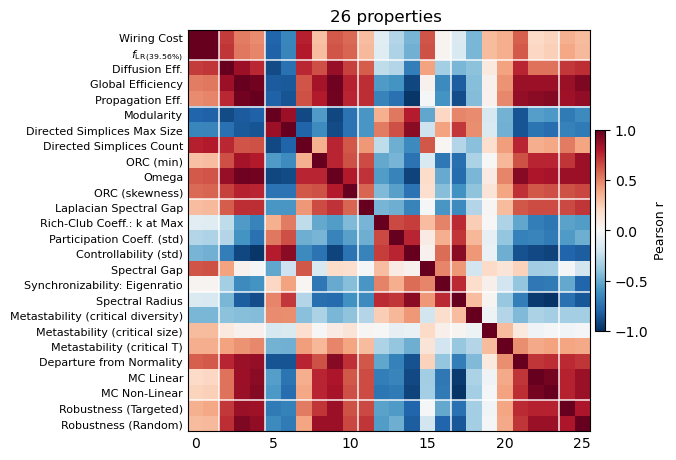

Saved correlation matrix to /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/corr_matrix_categorised_clean_main_selected_props_with_mc.pdf
cols_in_data: ['modularity', 'omega', 'directed_simplices_count', 'directed_simplices_max_size', 'global_efficiency', 'diffusion_efficiency', 'propagation_efficiency', 'wiring_cost', 'proportion_long_range_connections_0.3956', 'rich_club_coefficient_rc_k_at_max', 'spectral_radius', 'spectral_gap', 'synchronizability_eigenratio_eigenratio', 'algebraic_connectivity_laplacian_spectral_gap', 'departure_from_normality_schur', 'repertoire_sweep_weighted_by_distances_T_critical', 'repertoire_sweep_weighted_by_distances_size_critical', 'repertoire_sweep_weighted_by_distances_diversity_critical', 'participation_coefficient_pc_std', 'ollivier_ricci_curvature_orc_min', 'ollivier_ricci_curvature_orc_skewness', 'targeted_attack_robustness_rob_targeted_auc', 'targeted_attack_robustness_rob_random_auc', 'nct_control_std', '

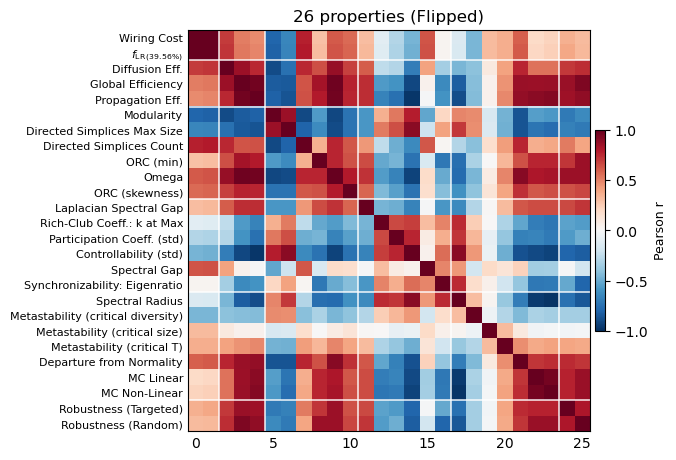

Saved correlation matrix to /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/corr_matrix_categorised_flipped_clean_main_selected_props_with_mc.pdf


In [15]:

# 3. Correlation Matrix Plotting
print("Generating correlation matrices...")
plot_clustered_correlation_matrix(huge_df[active_features], meta, f"corr_matrix_categorised_clean_{appendix}.pdf")

# # Flipping specific properties for better clustering logic
# properties_to_flip = [
#     "rich_club_coefficient_rc_k_at_max", 
#     "directed_simplices_count",
#     "participation_coefficient_pc_frac_connector",
#     "community_synchronization_vulnerability_n_communities",
#     "participation_coefficient_n_communities",
#     "repertoire_sweep_weighted_by_distances_diversity_critical"
# ]
# for prop in properties_to_flip:
#     if prop in huge_df.columns:
#         huge_df[prop] = -huge_df[prop]
        
plot_clustered_correlation_matrix(huge_df[active_features], meta, f"corr_matrix_categorised_flipped_clean_{appendix}.pdf", title_suffix="(Flipped)")


In [16]:

# ── 2. Sort variables by category, then section ───────────────────────────────
# cols_in_data = [c for c in huge_df.columns if c in meta.index]

def sort_key(col):
    row = meta.loc[col]
    cat = row["Category"] if pd.notna(row["Category"]) else "ZZZ"
    cat_idx = CATEGORY_ORDER.index(cat) if cat in CATEGORY_ORDER else len(CATEGORY_ORDER)
    return (cat_idx,) #  str(row["section"]))

cols_sorted_by_cat = sorted(active_features, key=sort_key)

# ── 3. Within-category hierarchical clustering ────────────────────────────────
corr_full = huge_df[active_features].corr()

final_order = []
for cat in CATEGORY_ORDER:
    cat_cols = [c for c in cols_sorted_by_cat if meta.loc[c, "Category"] == cat]
    if len(cat_cols) == 0:
        continue
    if len(cat_cols) == 1:
        final_order.extend(cat_cols)
        continue
    sub_corr = corr_full.loc[cat_cols, cat_cols].fillna(0)
    dist = np.clip(1 - sub_corr.values, 0, 2)
    np.fill_diagonal(dist, 0)
    Z = linkage(squareform(dist, checks=False), method="average")
    final_order.extend([cat_cols[i] for i in leaves_list(Z)])

# Append any uncategorised variables at the end
final_order.extend([c for c in active_features if c not in final_order])

# ── 4. Reorder & label ────────────────────────────────────────────────────────
reduced_corr = corr_full.loc[final_order, final_order]
new_labels = [SELECTED_PROPERTIES_NAMES.get(c, c) for c in final_order]

# ── 5. Plot ───────────────────────────────────────────────────────────────────
n = len(final_order)
fig = plt.figure(figsize=viz.cm_to_inch((18,12)))

gs = gridspec.GridSpec(1, 1, left=0.22, right=0.97, top=0.97, bottom=0.12)
ax = fig.add_subplot(gs[0])

im = ax.imshow(
    reduced_corr.values,
    cmap="RdBu_r", vmin=-1, vmax=1,
    aspect="equal", 
    interpolation="none",
)

# White dividers between categories
boundaries, prev_cat = [0], meta.loc[final_order[0], "Category"]
for i, c in enumerate(final_order[1:], start=1):
    curr_cat = meta.loc[c, "Category"] if c in meta.index else None
    if curr_cat != prev_cat:
        boundaries.append(i)
        prev_cat = curr_cat
boundaries.append(n)

for b in boundaries[1:-1]:
    ax.axhline(b - 0.5, color="white", linewidth=1.2, alpha=0.85)
    ax.axvline(b - 0.5, color="white", linewidth=1.2, alpha=0.85)

# Tick labels
# ax.set_xticks(np.arange(n))
# ax.set_xticklabels(new_labels, rotation=90, fontsize=8, ha="right")
ax.set_yticks(np.arange(n))
ax.set_yticklabels(new_labels, fontsize=8)
ax.tick_params(axis="both", which="both", length=0)

# ── 6. Category brackets on the left ─────────────────────────────────────────
moving_stuff = -0.5
BRACKET_X = -0.20 + moving_stuff
SERIF_W   = 0.005 
LABEL_X   = -0.21 + moving_stuff
trans     = ax.transAxes

cat_row_spans = {}
for row_i, c in enumerate(final_order):
    cat = meta.loc[c, "Category"] if c in meta.index else "Other"
    cat_row_spans.setdefault(cat, [row_i, row_i])[1] = row_i

def row_to_y(row_i, n):
    return 1.0 - (row_i + 0.5) / n

for cat, (r0, r1) in cat_row_spans.items():
    colour  = CATEGORY_COLOURS.get(cat, "#444444")
    weird_adapter = 0.00085
    y_top   = row_to_y(r0, n) + 0.5 / n + weird_adapter
    y_bot   = row_to_y(r1, n) - 0.5 / n - weird_adapter
    y_mid   = (y_top + y_bot) / 2
    kw      = dict(xycoords=trans, textcoords=trans, annotation_clip=False,
                   arrowprops=dict(arrowstyle="-", color=colour, lw=1.5))

    ax.annotate("", xy=(BRACKET_X, y_bot),       xytext=(BRACKET_X, y_top),   **kw)  # vertical bar
    ax.annotate("", xy=(BRACKET_X, y_top),        xytext=(BRACKET_X+SERIF_W, y_top), **kw)  # top serif
    ax.annotate("", xy=(BRACKET_X, y_bot),        xytext=(BRACKET_X+SERIF_W, y_bot), **kw)  # bottom serif
    ax.text(LABEL_X, y_mid, cat, transform=trans,
            ha="right", va="center", fontsize=8, fontweight="bold",
            color=colour, clip_on=False)

cbar = fig.colorbar(im, ax=ax, shrink=0.5, pad=0.01)
cbar.set_label("Pearson r", fontsize=9)
ax.set_title(f"{n} properties", # Correlation Matrix - {n} metrics (ordered by category, clustered within)",
            #  fontsize=11, 
            #  pad=8
             )

# plt.savefig(output_folder / "corr_matrix_categorised_flipped.pdf", dpi=150, bbox_inches="tight")
# print(output_folder / "corr_matrix_categorised_flipped.pdf")
plt.show()

KeyError: 'degree_gini'

Running PCA (all datasets)...



--- PCA Explained Variance ---
PC1: 62.49%
PC2: 14.73%
PC3: 4.82%


/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul

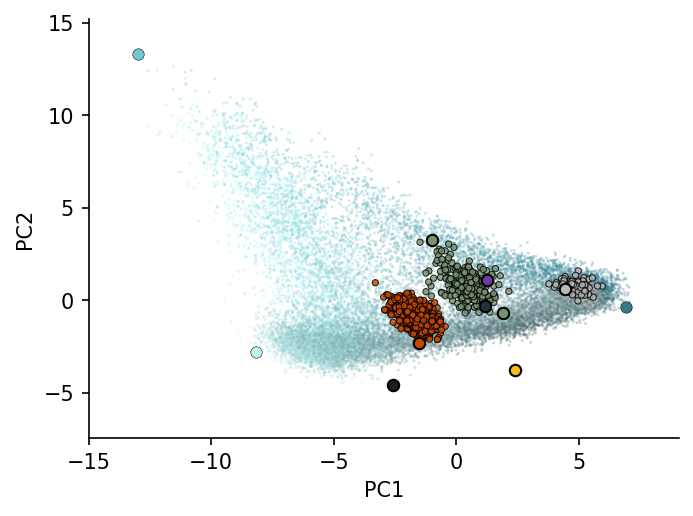

Saved PCA morphospace to /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_morphospace_remaining_main_selected_props_with_mc.pdf


In [ ]:

# 4. Run PCA & Test Morphospace against Function (all datasets)
print("Running PCA (all datasets)...")
pca, pca_result, scaled_data, used_features = run_pca_and_correlate(huge_df, active_features, excluded_features)

suffix = "_remaining" if USE_REMAINING_CATEGORIES_ONLY else "_all"


def plot_pca_morphospace(pca_result, huge_df, pca, output_filename):
    """PC1 vs PC2 scatter with highlighted corners and special-dataset points."""
    GNM_DATASET = "hcp_schaefer_100_dataset_gnm"
    SPECIAL_DATASETS = [
        "kaysons_generated_networks_routing",
        "kaysons_generated_networks_diffusion",
        "kaysons_generated_networks_propagation",
        "ring_lattice_networks",
        "erdos_renyi_networks",
    ]

    # ── Corner detection ──────────────────────────────────────────────────────
    corners_full = _find_corners(pca_result)

    # corners_no_gnm: searched only within lexis_developing + MaMI
    subset_mask = (
        (huge_df["dataset"] == "lexis_data_developing") |
        (huge_df["dataset"] == "suarez_MaMI_dataset")
    ).values
    orig_idx_subset = np.where(subset_mask)[0]
    corners_no_gnm_filtered = _find_corners(pca_result[subset_mask])
    corners_no_gnm = {
        name: int(orig_idx_subset[filt_idx])
        for name, filt_idx in corners_no_gnm_filtered.items()
    }

    # special: first row of each special dataset
    special_indices = {
        ds: int(huge_df.index[huge_df["dataset"] == ds][0])
        for ds in SPECIAL_DATASETS
        if (huge_df["dataset"] == ds).any()
    }

    # ── Build highlighted lookup ──────────────────────────────────────────────
    highlighted = {}
    for corner_name, idx in corners_full.items():
        ds = huge_df["dataset"].iloc[idx]
        highlighted[f"Overall · {corner_name.replace('_', ' ')}"] = {
            "idx": idx, "color": COLOR_SCHEME[ds], "source": "full"
        }
    for corner_name, idx in corners_no_gnm.items():
        ds = huge_df["dataset"].iloc[idx]
        highlighted[f"No-GNM · {corner_name.replace('_', ' ')}"] = {
            "idx": idx, "color": COLOR_SCHEME[ds], "source": "no_gnm"
        }
    for ds_key, idx in special_indices.items():
        highlighted[f"Special · {LABEL_MAP[ds_key]}"] = {
            "idx": idx, "color": COLOR_SCHEME[ds_key], "source": "special"
        }

    # ── Background scatter ────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=viz.cm_to_inch((12, 9)), dpi=150) # 18, 12)), dpi=150)

    for ds in huge_df["dataset"].unique():
        mask = (huge_df["dataset"] == ds).values
        ax.scatter(
            pca_result[mask, 0], pca_result[mask, 1],
            c=huge_df[mask]["color_dataset"],
            label=LABEL_MAP.get(ds, ds),
            alpha=0.3 if ds == GNM_DATASET else 0.8,
            s=2 if ds == GNM_DATASET else 9,
            edgecolors="none" if ds == GNM_DATASET else "black",
            linewidths=0 if ds == GNM_DATASET else 0.5,
            zorder=1,
            rasterized=True if ds == GNM_DATASET else False,
        )

    # ── Highlighted points ────────────────────────────────────────────────────
    for label, info in highlighted.items():
        idx = info["idx"]
        linewidth = 0.25 if info["source"] == "full" else 1 # 1.4
        ax.scatter(
            pca_result[idx, 0], pca_result[idx, 1],
            color=huge_df["color_dataset"].iloc[idx],
            s=30, # 50,
            zorder=6,
            edgecolors="black",
            linewidths=linewidth,
        )

    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

    buffer_x = 1
    buffer_y = 1
    ax.set_xlim(ax.get_xlim()[0] - buffer_x, ax.get_xlim()[1] + buffer_x)
    ax.set_ylim(ax.get_ylim()[0] - 2 * buffer_y, ax.get_ylim()[1] + buffer_y)

    plt.tight_layout()
    output_path = OUTPUT_FOLDER / output_filename
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    # plt.close()
    plt.show()
    print(f"Saved PCA morphospace to {output_path}")



plot_pca_morphospace(pca_result, huge_df, pca, f"pca_morphospace{suffix}_{appendix}.pdf")


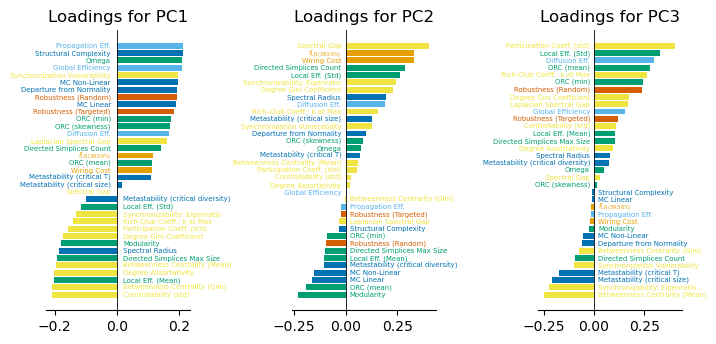

Saved PCA loadings to /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_loadings_remaining_main_selected_props_with_mc.pdf


In [ ]:

def plot_pca_loadings(pca, used_features, meta, output_filename):
    """Horizontal bar chart of PCA loadings for PC1–PC3, coloured by category."""
    loadings     = pca.components_.T          # (n_features, n_components)
    metric_names = np.array(used_features)
    num_metrics  = len(metric_names)

    fig, axs = plt.subplots(nrows=1, ncols=3,
                            figsize=viz.cm_to_inch((18,9)), # 40, 12)),
                            sharex=False)

    for i in range(3):
        ordered_pc_i    = np.argsort(loadings[:, i])
        loadings_sorted = loadings[ordered_pc_i]
        names_sorted    = metric_names[ordered_pc_i]
        names_long      = [SELECTED_PROPERTIES_NAMES[m] for m in names_sorted] # PROPERTY_NAMES.get(m, m) for m in names_sorted]

        bar_colours = []
        for m in names_sorted:
            cat = meta.loc[m, "Category"] if m in meta.index else None
            bar_colours.append(CATEGORY_COLOURS.get(cat, "#AAAAAA"))

        axs[i].barh(range(num_metrics), loadings_sorted[:, i], color=bar_colours)
        axs[i].axvline(0, color="black", linewidth=0.6)
        axs[i].set_title(f"Loadings for PC{i+1}")
        axs[i].set_yticks([])

        PAD = 0.02
        for j, (val, name, colour) in enumerate(zip(loadings_sorted[:, i], names_long, bar_colours)):
            if val >= 0:
                axs[i].text(-PAD, j, name, ha="right", va="center", fontsize=5, # 6.5, 
                            color=colour)
            else:
                axs[i].text( PAD, j, name, ha="left",  va="center", fontsize=5, # 6.5, 
                            color=colour)

        axs[i].spines["top"].set_visible(False)
        axs[i].spines["right"].set_visible(False)
        axs[i].spines["left"].set_visible(False)

    cats_present = [c for c in meta["Category"].value_counts().index if c in CATEGORY_COLOURS]
    handles = [mpatches.Patch(color=CATEGORY_COLOURS[cat], label=cat) for cat in cats_present]
    # fig.legend(handles=handles, title="Category",
    #            bbox_to_anchor=(1.01, 0.5), loc="center left", fontsize=8)

    plt.tight_layout()
    output_path = OUTPUT_FOLDER / output_filename
    plt.savefig(output_path, bbox_inches="tight")
    # plt.close()
    plt.show()
    print(f"Saved PCA loadings to {output_path}")





plot_pca_loadings(pca, used_features, meta, f"pca_loadings{suffix}_{appendix}.pdf")


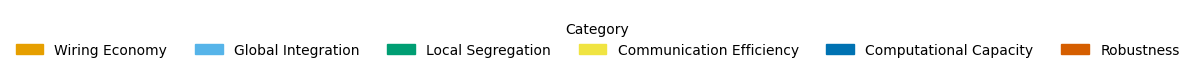

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/category_legend.pdf


In [ ]:
# from config import CATEGORY_ORDER, CATEGORY_COLOURS

fig = plt.figure(figsize=viz.cm_to_inch((12, 2)))

handles = [mpatches.Patch(color=CATEGORY_COLOURS[cat], label=cat) for cat in CATEGORY_ORDER]
fig.legend(
    handles=handles,
    title="Category",
    ncol=6,
    loc="center",
    frameon=False
)

plt.axis("off")
output_path = OUTPUT_FOLDER / "category_legend.pdf"
plt.savefig(output_path, bbox_inches="tight")
plt.show()

print(output_path)

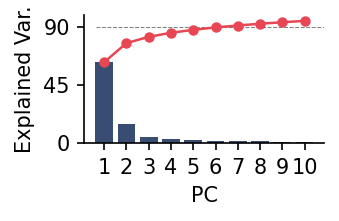

Saved scree plot to /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_scree_remaining_main_selected_props_with_mc.pdf


In [ ]:

def plot_scree(pca, output_filename):
    """Bar + cumulative line scree plot."""
    evr = pca.explained_variance_ratio_ * 100
    n   = len(evr)

    fig, ax = plt.subplots(figsize=viz.cm_to_inch((6,4)), dpi=150)

    # Horizontal line at 90%
    ax.axhline(90, 0.05, 10, color="grey", linestyle="--", lw=0.5) # lw=0.5, alpha=0.4)
    # Ticks on y for 0, 45, 90 
    ax.set_yticks([0, 45, 90])


    ax.bar(range(1, n + 1), evr, color="#394D73", label="Individual")
    ax.plot(range(1, n + 1), np.cumsum(evr), color="#E84653",
            marker="o", markersize=4, linewidth=1.2, label="Cumulative")
    # ax.set_xlabel("Principal Component")
    ax.set_xlabel("PC")
    # ax.set_ylabel("Explained Variance (%)")
    ax.set_ylabel("Explained Var.")
    ax.set_xticks(range(1, n + 1))
    # ax.legend(fontsize=8, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)



    plt.tight_layout()
    output_path = OUTPUT_FOLDER / output_filename
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    # plt.close()
    plt.show()
    print(f"Saved scree plot to {output_path}")



plot_scree(pca, f"pca_scree{suffix}_{appendix}.pdf")


{'Wiring Economy': (np.float64(1.0706047788483128), np.float64(1.4954063443987127)), 'Global Integration': (np.float64(2.74646437622056), np.float64(0.40580906629541524)), 'Local Segregation': (np.float64(0.5734680524395371), np.float64(-0.0149477812040405)), 'Communication Efficiency': (np.float64(-4.922420258013249), np.float64(2.91229625984108)), 'Computational Capacity': (np.float64(2.917731330876483), np.float64(0.0984720997616706)), 'Robustness': (np.float64(1.746188591841612), np.float64(-0.26967353167322533))}
Category vectors in PCA space
(weighted by loading magnitude)


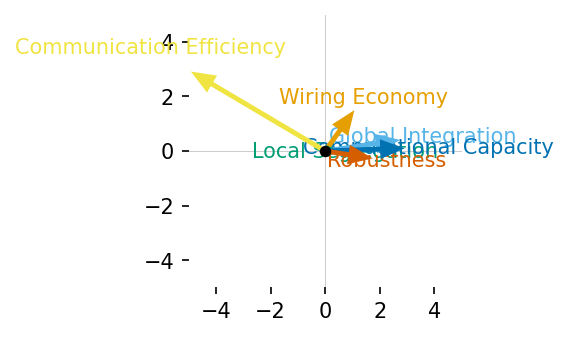

Saved category quivers to /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_quivers_remaining_main_selected_props_with_mc_with_labels.pdf
{'Wiring Economy': (np.float64(1.0706047788483128), np.float64(1.4954063443987127)), 'Global Integration': (np.float64(2.74646437622056), np.float64(0.40580906629541524)), 'Local Segregation': (np.float64(0.5734680524395371), np.float64(-0.0149477812040405)), 'Communication Efficiency': (np.float64(-4.922420258013249), np.float64(2.91229625984108)), 'Computational Capacity': (np.float64(2.917731330876483), np.float64(0.0984720997616706)), 'Robustness': (np.float64(1.746188591841612), np.float64(-0.26967353167322533))}
Category vectors in PCA space
(weighted by loading magnitude)


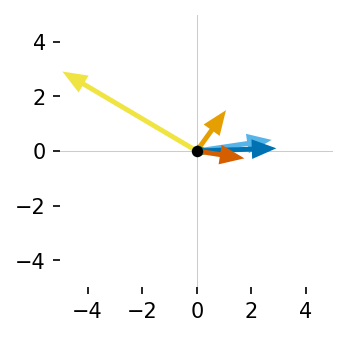

Saved category quivers to /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_quivers_remaining_main_selected_props_with_mc_no_labels.pdf
{'Wiring Economy': (np.float64(1.0706047788483128), np.float64(1.4954063443987127)), 'Global Integration': (np.float64(2.74646437622056), np.float64(0.40580906629541524)), 'Local Segregation': (np.float64(0.5734680524395371), np.float64(-0.0149477812040405)), 'Communication Efficiency': (np.float64(-4.922420258013249), np.float64(2.91229625984108)), 'Computational Capacity': (np.float64(2.917731330876483), np.float64(0.0984720997616706)), 'Robustness': (np.float64(1.746188591841612), np.float64(-0.26967353167322533))}
Category vectors in PCA space
(weighted by loading magnitude)


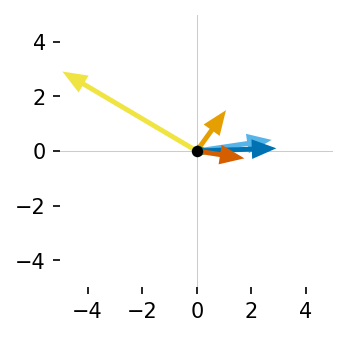

Saved category quivers to /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/pca_quivers_remaining_main_selected_props_with_mc_no_labels.pdf


In [ ]:



def plot_category_quivers(loading_and_cat_df, meta, output_filename, with_labels=False, equal_axes=True):

    """
    Quiver plot of category-aggregate loading vectors in PC1–PC2 space.

    Each category arrow = sum of biplot-scaled loadings for all variables in that category.
    """
    cat_vectors = {}
    for cat in CATEGORY_COLOURS:
        cat_vars = [
            c for c in loading_and_cat_df.index
            if c in meta.index and meta.loc[c, "Category"] == cat
        ]
        if not cat_vars:
            continue
        cat_loads = loading_and_cat_df.loc[cat_vars]
        vx = cat_loads["PC1"].sum()
        vy = cat_loads["PC2"].sum()
        cat_vectors[cat] = (vx, vy)
        
    print(cat_vectors)

    fig, ax = plt.subplots(figsize=viz.cm_to_inch((6,6)), 
                           dpi=150)

    ax.axhline(0, color="grey", lw=0.5, alpha=0.4)
    ax.axvline(0, color="grey", lw=0.5, alpha=0.4)
    ax.scatter([0], [0], color="black", s=20, zorder=6)

    for cat, (vx, vy) in cat_vectors.items():
        colour = CATEGORY_COLOURS[cat]
        ax.quiver(
            0, 0, vx, vy,
            angles="xy", scale_units="xy", scale=1,
            color=colour, 
            width=0.018, # 012,
            headwidth=4,
            headlength=5, headaxislength=5,
            zorder=5,
        )
        if with_labels:
            nudge = 1.3 # 1.15
            ax.text(vx * nudge, vy * nudge, cat,
                    ha="center", va="center", color=colour)

    # max_val = max(np.sqrt(vx**2 + vy**2) for vx, vy in cat_vectors.values()) # * 1.4
    # maximum value in any direction (PC1 or PC2)
    max_val = max([max(abs(vx), abs(vy)) for vx, vy in cat_vectors.values()]) # * 1.4
    # # ax.set_xlim(-max_val, max_val)
    # # ax.set_ylim(-max_val, max_val)
    # ax.set_xlim(-max_val, max_val)
    # ax.set_ylim(-max_val, max_val)
    # if equal_axes:
    #     ax.set_aspect("equal")
    # else:
    #     plt.tight_layout()  # only apply when axes are free to scale

    # if equal_axes:
    #     ax.set_xlim(-max_val, max_val)
    #     ax.set_ylim(-max_val, max_val)
    ax.set_aspect("equal", adjustable="box")
    # else:
    #     ax.set_xlim(-max_val, max_val)
    #     ax.set_ylim(-max_val, max_val)

    max_val = 5
    ax.set_xlim(-max_val, max_val)
    ax.set_ylim(-max_val, max_val)
    ticks = [-4, -2, 0, 2, 4]
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    # ax.set_aspect("equal")
    # ax.set_xlabel("PC1", fontsize=9)
    # ax.set_ylabel("PC2", fontsize=9)
    # ax.set_title("Category vectors in PCA space\n(weighted by loading magnitude)", fontsize=9)
    print("Category vectors in PCA space\n(weighted by loading magnitude)")

    for spine in ax.spines.values():
        spine.set_visible(False)

    # plt.tight_layout()
    output_path = OUTPUT_FOLDER / output_filename
    plt.savefig(output_path, bbox_inches="tight")
    # plt.close()
    plt.show()
    print(f"Saved category quivers to {output_path}")


loading_and_cat_df = compute_biplot_loadings(pca, used_features)
with_labels = False
plot_category_quivers(loading_and_cat_df, meta, f"pca_quivers{suffix}_{appendix}_with_labels.pdf", with_labels=True)
with_labels = False
plot_category_quivers(loading_and_cat_df, meta, f"pca_quivers{suffix}_{appendix}_no_labels.pdf", with_labels=False)

plot_category_quivers(loading_and_cat_df, meta, 
                      f"pca_quivers{suffix}_{appendix}_no_labels.pdf", 
                      with_labels=False, 
                      equal_axes=True)


# GNM without MC & Later correlation (skipped currently, as this affects later code) 

In [ ]:

# # 5. GNM-only morphospace: refit PCA on GNM rows only, correlate with IPC/MC
# #    ipc_ipc_* columns are GNM-only and not in Excel metadata / remaining_categories,
# #    so we detect them directly from huge_df rather than routing through excluded_features.
# ipc_cols = [c for c in huge_df.columns if "ipc_ipc_" in c]
# print(f"\nFound {len(ipc_cols)} ipc_ipc_* columns for GNM correlation.")
# gnm_ipc_corr_df = correlate_gnm_morphospace_with_ipc(huge_df, active_features, ipc_cols)


In [ ]:

# 6. Morphospace re-colored by each excluded feature
print("Plotting morphospace colored by functional features...")
plot_functional_coloring(
    pca_result, huge_df, excluded_features, # excluded_comp,
    "Computational / Memory Capacity", f"pca_coloring_comp_capacity_{appendix}.pdf",
)


Plotting morphospace colored by functional features...


In [ ]:

# # 7. Summary bar chart: PC axis correlations with functional features
# print("Plotting axis–feature correlations...")
# plot_axis_correlations(
#     pca_result, huge_df, excluded_features,  # excluded_memory, excluded_comp,
#     f"pca_axis_correlations_{appendix}.pdf",
# )
# # Summary: features with |r| > 0.5 on any PC
# strong = gnm_ipc_corr_df[gnm_ipc_corr_df["r"].abs() > 0.5].sort_values("r", key=abs, ascending=False)
# if not strong.empty:
#     print("\n--- Strong correlations (|r| > 0.5) in GNM morphospace ---")
#     print(strong.to_string(index=False))


In [ ]:


def find_corners(pca_result_2d):
    """Return a dict of corner name → row index within pca_result_2d."""
    return {
        "top_left":     int(np.argmax( pca_result_2d[:, 1])),
        "bottom_left":  int(np.argmax(-pca_result_2d[:, 0] - pca_result_2d[:, 1])),
        "bottom_right": int(np.argmax( pca_result_2d[:, 0] - pca_result_2d[:, 1])),
    }

In [ ]:
# ── Corners in the full selected-properties PCA space ────────────────────────
corners_full = find_corners(pca_result)

print("Corner points (full dataset):")
for name, idx in corners_full.items():
    ds = huge_df["dataset"].iloc[idx]
    print(f"  {name}: idx={idx}, PC1={pca_result[idx,0]:.2f}, PC2={pca_result[idx,1]:.2f}, dataset={ds}")


Corner points (full dataset):
  top_left: idx=5626, PC1=-13.00, PC2=13.30, dataset=hcp_schaefer_100_dataset_gnm
  bottom_left: idx=5304, PC1=-8.19, PC2=-2.79, dataset=hcp_schaefer_100_dataset_gnm
  bottom_right: idx=11210, PC1=6.94, PC2=-0.36, dataset=hcp_schaefer_100_dataset_gnm


In [ ]:
print(pca_result.shape[0], len(active_features))  # these must match

25957 35


In [ ]:
pca_result

array([[-1.53861782,  2.44600579,  2.2058563 , ..., -0.34248553,
         0.17311087, -0.05779741],
       [ 4.10246527,  0.39804349,  0.54761596, ...,  0.19890215,
        -0.55277311,  0.24394118],
       [ 5.06395643,  0.06677714, -0.52247796, ...,  0.25688975,
         0.50972055,  0.21976703],
       ...,
       [ 5.15077147,  0.83333567, -1.44319075, ...,  0.70875099,
         1.25575155, -0.20690806],
       [ 4.06885363,  0.8409239 , -0.71792632, ..., -1.82219567,
         0.1654252 , -0.30809155],
       [ 5.25582748,  0.49682702, -0.99852924, ...,  0.01142156,
        -0.30599698, -0.64427478]], shape=(25957, 10))

In [ ]:
scaled_data

array([[-0.23354484,  1.35722739,  0.38142844, ...,  0.22571776,
         0.45165587,  1.60939988],
       [-0.96067722, -0.62715621, -0.80843018, ..., -0.79736746,
        -0.89543694,  0.04506415],
       [-1.02584867, -1.13422852, -0.90684289, ..., -1.19498793,
        -1.25848697, -1.17972785],
       ...,
       [-0.98817495, -0.87587035, -1.33300111, ..., -0.9172404 ,
        -1.20736912, -0.89268373],
       [-0.97743519, -0.77003995, -0.75519099, ..., -0.96599051,
        -1.09614237, -0.77759409],
       [-0.90580861, -0.88551437, -1.19794919, ..., -0.97271711,
        -1.20830954, -1.15575166]], shape=(25957, 35))

In [ ]:
# sel_scaled = scaled_data

In [ ]:

cat_order_present = [c for c in CATEGORY_ORDER if c in meta["Category"].values]

def get_cat_values(row_vals: np.ndarray, feature_cols: list, cat_order: list) -> np.ndarray:
    """Return mean of z-scored feature values within each category (one value per cat)."""
    result = []
    for cat in cat_order:
        cols = [c for c in feature_cols if c in meta.index and meta.loc[c, "Category"] == cat]
        if not cols:
            result.append(np.nan)
            continue
        idxs = [feature_cols.index(c) for c in cols]
        result.append(np.nanmean(row_vals[idxs]))
    return np.array(result)


In [ ]:
huge_df

,transitivity,avg_clustering,modularity,degree_gini,degree_assortativity,omega,structural_complexity,directed_simplices_count,directed_simplices_max_size,char_path_length,...,local_efficiency_stats_std,local_efficiency_stats_min,local_efficiency_stats_max,gromov_hyperbolicity,dataset,eta,gamma,color_dataset,resistance_distance_mean,resistance_distance_std
0,0.325354,0.360510,0.363236,0.337838,0.262612,0.341296,0.765869,293.0,7.0,2.689091,...,0.233282,0.0,1.000000,1.5,hcp_schaefer_100_dataset_gnm,1.204082,0.304082,"(0.3793484680412771, 0.6577537079356909, 0.692...",NaN,NaN
1,0.130197,0.131503,0.257959,0.179879,0.034247,0.798096,0.854853,324.0,5.0,2.251111,...,0.147229,0.0,0.722222,2.0,hcp_schaefer_100_dataset_gnm,-4.857143,0.663265,"(0.6666552266809346, 0.7631623986031614, 0.763...",NaN,NaN
2,0.088385,0.088808,0.248524,0.139515,0.015359,0.867891,0.865043,343.0,4.0,2.230505,...,0.079855,0.0,0.433333,1.5,hcp_schaefer_100_dataset_gnm,-5.979592,0.124490,"(0.435756342095102, 0.4925153719235967, 0.4849...",NaN,NaN
3,0.208936,0.245677,0.313943,0.238707,0.066429,0.622053,0.831857,308.0,5.0,2.315758,...,0.170515,0.0,1.000000,1.5,hcp_schaefer_100_dataset_gnm,0.530612,0.146939,"(0.32380788819100603, 0.5767760154705456, 0.61...",NaN,NaN
4,0.335465,0.344261,0.380653,0.219535,0.208672,0.421257,0.800907,221.0,8.0,2.409091,...,0.195101,0.0,1.000000,2.0,hcp_schaefer_100_dataset_gnm,-3.959184,0.932653,"(0.7718075028288833, 0.9008893391251005, 0.901...",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25952,0.107516,0.110221,0.266561,0.174081,-0.073022,0.835722,0.858644,325.0,4.0,2.236768,...,0.101323,0.0,0.511111,NaN,erdos_renyi_networks,NaN,NaN,#B8B8B8,NaN,NaN
25953,0.098725,0.095897,0.262316,0.170545,-0.015867,0.858935,0.859727,343.0,4.0,2.234141,...,0.113652,0.0,0.511111,NaN,erdos_renyi_networks,NaN,NaN,#B8B8B8,NaN,NaN
25954,0.092500,0.093525,0.253978,0.160081,-0.066432,0.861562,0.860554,336.0,4.0,2.234141,...,0.095645,0.0,0.418529,NaN,erdos_renyi_networks,NaN,NaN,#B8B8B8,NaN,NaN
25955,0.108002,0.106612,0.255533,0.168505,0.044465,0.840029,0.858808,334.0,4.0,2.245455,...,0.101976,0.0,0.433333,NaN,erdos_renyi_networks,NaN,NaN,#B8B8B8,NaN,NaN


In [ ]:
print(scaled_data.shape[1], len(active_features))  # these must match

35 35


In [ ]:
# feature_cols = active_features
meta = meta.loc[active_features]
meta

,Category
var,
modularity,Local Segregation
degree_gini,Communication Efficiency
degree_assortativity,Communication Efficiency
omega,Local Segregation
structural_complexity,Computational Capacity
directed_simplices_count,Local Segregation
directed_simplices_max_size,Local Segregation
global_efficiency,Global Integration
diffusion_efficiency,Global Integration


In [ ]:
cat_scaled_all = np.array([
    get_cat_values(scaled_data[i], active_features, cat_order_present)
        for i in range(len(scaled_data))
])

# Re-z-score each category column across all networks
cat_scaled_all = np.apply_along_axis(zscore, 0, cat_scaled_all)

cat_ylim = (np.nanmin(cat_scaled_all), np.nanmax(cat_scaled_all))



In [ ]:

# Only get datasets that are mami or hcp 
mask = (huge_df["dataset"] == "lexis_data_developing").values | (huge_df["dataset"] == "suarez_MaMI_dataset").values
orig_idx = np.where(mask)[0]        # positions in sel_scaled / pca_result

# PCA results restricted to non-GNM networks
pca_result_no_gnm = pca_result[mask]

# Find corners inside the filtered view (0-indexed within the subset)
corners_no_gnm_filtered = find_corners(pca_result_no_gnm)

# ── Remap to original row indices for sel_scaled ──────────────────────────────
# Without this step, e.g. filtered_idx=5 would incorrectly retrieve row 5 of
# sel_scaled (a GNM network), not the 5th non-GNM network.
corners_no_gnm = {
    name: int(orig_idx[filt_idx])
    for name, filt_idx in corners_no_gnm_filtered.items()
}

SPECIAL_DATASETS = [
    "kaysons_generated_networks_routing",
    "kaysons_generated_networks_diffusion",
    "kaysons_generated_networks_propagation",
    "ring_lattice_networks",
    "erdos_renyi_networks",
]

# # Original row index for single-network datasets
special_indices = {
    ds: int(huge_df.index[huge_df["dataset"] == ds][0])
    for ds in SPECIAL_DATASETS
}

In [ ]:
# # ── 2. Updated get_neighbours (unchanged logic, works with cat_scaled_all too) ─
# from sklearn.metrics import pairwise_distances

# def get_neighbours(orig_idx, embed, n=5, exclude_gnm=False, df_label=None, gnm_name=None):
#     dists = pairwise_distances(embed[orig_idx:orig_idx + 1], embed)[0]
#     dists[orig_idx] = np.inf
#     if exclude_gnm and df_label is not None:
#         dists[(df_label["dataset"] == gnm_name).values] = np.inf
#     return np.argsort(dists)[:n].tolist()


# # ── 3. Rebuild panels using category values ───────────────────────────────────

# panels = []

# for corner_name, orig_idx in corners_full.items():
#     ds    = huge_df["dataset"].iloc[orig_idx]
#     color = huge_df["color_dataset"].iloc[orig_idx] #### OR "black" OR COLOR_SCHEME[ds]
#     nb_idx  = get_neighbours(orig_idx, pca_result, n=5)
#     nb_vals = [cat_scaled_all[i] for i in nb_idx]      # ← cat-level rows
#     panels.append((
#         f"Overall · {corner_name.replace('_', ' ')}",
#         cat_scaled_all[orig_idx], 
#         color,                # ← cat-level row
#         f"spider_overall_{corner_name}.pdf",
#         nb_vals,
#     ))

# for corner_name, orig_idx in corners_no_gnm.items():
#     ds    = huge_df["dataset"].iloc[orig_idx]
#     color = COLOR_SCHEME[ds]
#     nb_idx  = get_neighbours(orig_idx, pca_result, n=5,
#                              exclude_gnm=True, df_label=huge_df, gnm_name="hcp_schaefer_100_dataset_gnm")
#     nb_vals = [cat_scaled_all[i] for i in nb_idx]
#     panels.append((
#         f"No-GNM · {corner_name.replace('_', ' ')}",
#         cat_scaled_all[orig_idx], color,
#         f"spider_no_gnm_{corner_name}.pdf",
#         nb_vals,
#     ))

# for ds_key, orig_idx in special_indices.items():
#     label_text = LABEL_MAP[ds_key]
#     color = COLOR_SCHEME[ds_key]
#     nb_idx  = get_neighbours(orig_idx, pca_result, n=5)
#     nb_vals = [cat_scaled_all[i] for i in nb_idx]
#     panels.append((
#         f"Special · {label_text}",
#         cat_scaled_all[orig_idx], color,
#         f"spider_special_{label_text.lower()}.pdf",
#         nb_vals,
#     ))
    
    
# # One empty one - no neighbors either, just to show the axes with category labels and no data. But make it have all rings visible to show the full scale of category values (unlike the others which may have some rings cut off if their max value is low)
# COLOR = "gray" # lightgray 
# panels.append((
#     "Categories only",
#     np.full(len(cat_order_present), np.nan),
#     COLOR,
#     "spider_categories_only.pdf",
#     None,
# ))

# # ── 4. Render ─────────────────────────────────────────────────────────────────

# all_corner_indices = (
#     list(corners_full.values()) +
#     list(corners_no_gnm.values()) +
#     list(special_indices.values())
# )
# # all_vals = np.concatenate([scaled_data[idx, rep_idx] for idx in all_corner_indices])

# # YLIM = (np.floor(all_vals.min()), np.ceil(all_vals.max()))
# YLIM = [-2, 2] # 4] # 10]
# RING_VALS = [-2, 0, 2] # -6, 2] # 

# # ── Spider drawing function ────────────────────────────────────────────────────

# # def make_spider_standalone(values, label, color, feature_labels, title, ylim, filepath):
# #     n = len(values)
# #     angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
# #     angles_closed = angles + angles[:1]
# #     vals_closed   = list(values) + [values[0]]

# #     fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True), dpi=50)

# #     # ── Limits & ticks ──
# #     ax.set_ylim(*ylim)
# #     ax.set_yticks(RING_VALS + [0]) # [-2, 0, 2])
# #     ax.set_yticklabels(RING_VALS + [0], fontsize=8, color="gray")

# #     # ── Remove outermost border ring ──
# #     ax.spines["polar"].set_visible(False)

# #     # ── Custom gridlines: draw manually so we can style zero differently ──
# #     ax.yaxis.grid(False)   # turn off auto y-gridlines
# #     ax.xaxis.grid(False)   # turn off auto x-gridlines (spokes we'll redraw)
# #     theta_ring = np.linspace(0, 2 * np.pi, 300)
# #     for r_val in RING_VALS: # [-2, 2]:
# #         ax.plot(theta_ring, np.full(300, r_val),
# #                 color="lightgray", linewidth=0.6, linestyle="--", zorder=0)
# #     # Zero ring — heavier
# #     ax.plot(theta_ring, np.zeros(300),
# #             color="gray", linewidth=1.8, linestyle="-", zorder=1)
# #     # Other rings: 
# #     for r_val in RING_VALS:  # YLIM: # [-2, 2]:
# #         theta_ring = np.linspace(0, 2 * np.pi, 300)
# #         ax.plot(theta_ring, np.full(300, r_val), color="lightgray", linewidth=0.6, linestyle="--", zorder=0)

# #     # Spoke lines
# #     for angle in angles:
# #         ax.plot([angle, angle], YLIM, # [ylim[0], ylim[1]],
# #                 color="lightgray", linewidth=0.5, linestyle="--", zorder=0)


# #     # ── Data ──
# #     ax.plot(angles_closed, vals_closed, color=color, linewidth=2.2, zorder=5)
# #     ax.fill(angles_closed, vals_closed, color=color, alpha=0.20, zorder=4)

# #     # ── Feature labels (spokes) — no angle labels by default ──
# #     ax.set_thetagrids([])          # hide spoke degree labels; add manually below
# #     ax.set_xticklabels([])

# #     ax.set_title(title, pad=16) # , fontsize=10, pad=16, fontweight="bold")

# #     plt.tight_layout()
# #     plt.savefig(filepath, dpi=150, bbox_inches="tight")
# #     plt.show()
# #     plt.close(fig)
# #     print(f"  Saved: {filepath.name}")

# def make_spider_standalone(values, label, color, feature_labels, title, ylim,
#                            filepath, neighbour_vals_list=None,
#                            axis_colors=None, ring_vals=None):
#     n = len(values)
#     angles        = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
#     angles_closed = angles + angles[:1]
#     vals_closed   = list(values) + [values[0]]
    
#     print(max(vals_closed))
#     ring_color = "gray"
#     if max(vals_closed) > 2: # 4:
#         ring_colors = [ring_color] * 5
#         tick_labels = ["-2", "0", "2", "4", "6"]
#         y_max_change = 0 
#     else: 
#     # elif max(vals_closed) > 0: # 2:
#         ring_colors = [ring_color] * 3 + ["white"]
#         tick_labels = ["-2", "0", "2", "", ""]
#         y_max_change = 2
#     # else:
#     #     ring_colors = [ring_color] * 2 + ["white"] * 2
#     #     tick_labels = ["-2", "0", "", "", ""]
#     #     y_max_change = 4

#     fig, ax = plt.subplots(figsize=viz.cm_to_inch((6,6)), subplot_kw=dict(polar=True), dpi=100)
#     ax.set_ylim(*ylim) # y_max)
#     # ax.set_ylim(ylim[0], ylim[1]-y_max_change) # y_max)
#     print(*ylim)
#     ax.spines["polar"].set_visible(False)
#     ax.yaxis.grid(False) 
#     ax.xaxis.grid(False)

#     theta_ring = np.linspace(0, 2 * np.pi, 300)

#     # Gridlines
#     ring_vals = ring_vals if ring_vals is not None else RING_VALS
#     print(ring_vals)
#     for i, r_val in enumerate(ring_vals):   
#         ax.plot(theta_ring, np.full(300, r_val),
#                 color=ring_colors[i], linewidth=0.5, # 0.6, 
#                 linestyle="--", zorder=0)
#         ax.yaxis.set_ticklabels(labels=tick_labels, 
#                                 fontdict={'verticalalignment': 'baseline',
#                                 'horizontalalignment': 'left'}) # center'}) # label_position("right")

#     ax.plot(theta_ring, np.zeros(300),
#             color=axis_colors, linewidth=1, # 1.8, 
#             linestyle="-", zorder=1)
    
#     for angle in angles:
#         ax.plot([angle, angle], [ylim[0], ylim[1]-y_max_change], # ylim,
#                 color=axis_colors, linewidth=0.5, # 0.5, 
#                 linestyle="--", zorder=0)

#     # Neighbour lines
#     alpha_fill = 0.05
#     linewidth  = 1
#     zorder     = 3
#     if neighbour_vals_list is not None:
#         for nb_vals in neighbour_vals_list:
#             nb_closed = list(nb_vals) + [nb_vals[0]]
#             ax.plot(angles_closed, nb_closed,
#                     color=color, #  if not "Overall" in label else "black", 
#                     linewidth=linewidth, 
#                     alpha=1, # 0.25, 
#                     zorder=zorder + 1)
#             ax.fill(angles_closed, nb_closed,
#                     color=color, alpha=alpha_fill, zorder=zorder)

#     # Main polygon
#     ax.fill(angles_closed, vals_closed, color=color, alpha=alpha_fill, zorder=zorder)
#     ax.plot(angles_closed, vals_closed,
#             color="black", # color if not "Overall" in label else "black", 
#             linewidth=linewidth, zorder=zorder + 1)

#     # # ── Category axis labels, colored per category ────────────────────────────
#     # ax.set_thetagrids(np.degrees(angles), labels=feature_labels, fontsize=7)
#     # for i, (label_text, angle) in enumerate(zip(feature_labels, angles)):
#     #     lbl_color = axis_colors[i] if axis_colors is not None else "black"
#     #     # Find the Text object matplotlib just created and recolor it
#     #     for txt in ax.get_xticklabels():
#     #         if txt.get_text() == label_text:
#     #             txt.set_color(lbl_color)
#     #             txt.set_fontweight("bold")
#     #             break
#     # Remove labels 
#     ax.set_thetagrids([])   

#     # x ticks should be gray
#     ax.tick_params(axis='y', labelcolor=axis_colors) # , labelsize=7)

#     ax.set_title(title) # , pad=16, fontsize=9)
#     plt.tight_layout()
#     plt.savefig(filepath, dpi=150, bbox_inches="tight")
#     plt.show()
#     plt.close(fig)
#     print(filepath)
    
    

# all_vals = np.nanmax([v for _, vals, *_ in panels for v in vals])
# dyn_ylim     = (cat_ylim[0], 2 if all_vals <= 2 else 4 if all_vals <= 4 else cat_ylim[1])
# # dyn_ring_vals = [r for r in RING_VALS if r <= dyn_ylim[1]]
# dyn_ring_vals = RING_VALS
# print(dyn_ring_vals)

# output_folder = OUTPUT_FOLDER / "spiders"
# output_folder.mkdir(exist_ok=True)

# for title, vals, color, fname, nb_vals in panels:
#     make_spider_standalone(
#         values          = vals,
#         label           = title,
#         color           = color,
#         feature_labels  = CATEGORY_ORDER, # cat_labels,        # ← category names
#         title           = title,
#         # ylim            = cat_ylim,
#         ylim            = dyn_ylim,
#         ring_vals       = dyn_ring_vals,
#         filepath        = output_folder / fname,
#         neighbour_vals_list = nb_vals,
#         axis_colors     = COLOR, # cat_axis_colors,   # ← per-category label colors
#     )



[-1, 0, 1, 2, 3, 4, 5, 6]
6.2860359346928325
-4 6.2860359346928325
[-1, 0, 1, 2, 3, 4, 5, 6]


/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/util

ValueError: 'a' is not a valid value for color: supported inputs are (r, g, b) and (r, g, b, a) 0-1 float tuples; '#rrggbb', '#rrggbbaa', '#rgb', '#rgba' strings; named color strings; string reprs of 0-1 floats for grayscale values; 'C0', 'C1', ... strings for colors of the color cycle; and pairs combining one of the above with an alpha value

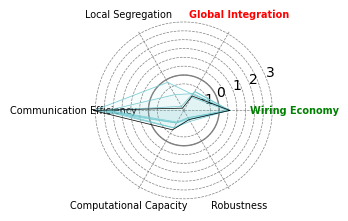

In [ ]:
# ── 2. Updated get_neighbours (unchanged logic, works with cat_scaled_all too) ─
from sklearn.metrics import pairwise_distances

def get_neighbours(orig_idx, embed, n=5, exclude_gnm=False, df_label=None, gnm_name=None):
    dists = pairwise_distances(embed[orig_idx:orig_idx + 1], embed)[0]
    dists[orig_idx] = np.inf
    if exclude_gnm and df_label is not None:
        dists[(df_label["dataset"] == gnm_name).values] = np.inf
    return np.argsort(dists)[:n].tolist()


# ── 3. Rebuild panels using category values ───────────────────────────────────

panels = []

for corner_name, orig_idx in corners_full.items():
    ds    = huge_df["dataset"].iloc[orig_idx]
    color = huge_df["color_dataset"].iloc[orig_idx] #### OR "black" OR COLOR_SCHEME[ds]
    nb_idx  = get_neighbours(orig_idx, pca_result, n=5)
    nb_vals = [cat_scaled_all[i] for i in nb_idx]      # ← cat-level rows
    panels.append((
        f"Overall - {corner_name.replace('_', ' ')}",
        cat_scaled_all[orig_idx], 
        color,                # ← cat-level row
        f"spider_overall_{corner_name}.pdf",
        nb_vals,
    ))

for corner_name, orig_idx in corners_no_gnm.items():
    ds    = huge_df["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    nb_idx  = get_neighbours(orig_idx, pca_result, n=5,
                             exclude_gnm=True, df_label=huge_df, gnm_name="hcp_schaefer_100_dataset_gnm")
    nb_vals = [cat_scaled_all[i] for i in nb_idx]
    panels.append((
        f"No-GNM - {corner_name.replace('_', ' ')}",
        cat_scaled_all[orig_idx], color,
        f"spider_no_gnm_{corner_name}.pdf",
        nb_vals,
    ))

for ds_key, orig_idx in special_indices.items():
    label_text = LABEL_MAP[ds_key]
    color = COLOR_SCHEME[ds_key]
    nb_idx  = get_neighbours(orig_idx, pca_result, n=5)
    nb_vals = [cat_scaled_all[i] for i in nb_idx]
    panels.append((
        f"Special - {label_text}",
        cat_scaled_all[orig_idx], color,
        f"spider_special_{label_text.lower()}.pdf",
        nb_vals,
    ))
    
    
# One empty one - no neighbors either, just to show the axes with category labels and no data. But make it have all rings visible to show the full scale of category values (unlike the others which may have some rings cut off if their max value is low)
COLOR = "gray" # lightgray 
panels.append((
    "Categories only",
    np.full(len(cat_order_present), np.nan),
    COLOR,
    "spider_categories_only.pdf",
    None,
))

# ── 4. Render ─────────────────────────────────────────────────────────────────

all_corner_indices = (
    list(corners_full.values()) +
    list(corners_no_gnm.values()) +
    list(special_indices.values())
)
# all_vals = np.concatenate([scaled_data[idx, rep_idx] for idx in all_corner_indices])

# YLIM = (np.floor(all_vals.min()), np.ceil(all_vals.max()))
YLIM = [-1, 2] # 4] # 10]
RING_VALS = [-1, 0, 1, 2, 3, 4, 5, 6] # -6, 2] # 

# ── Spider drawing function ────────────────────────────────────────────────────

# def make_spider_standalone(values, label, color, feature_labels, title, ylim, filepath):
#     n = len(values)
#     angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
#     angles_closed = angles + angles[:1]
#     vals_closed   = list(values) + [values[0]]

#     fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True), dpi=50)

#     # ── Limits & ticks ──
#     ax.set_ylim(*ylim)
#     ax.set_yticks(RING_VALS + [0]) # [-2, 0, 2])
#     ax.set_yticklabels(RING_VALS + [0], fontsize=8, color="gray")

#     # ── Remove outermost border ring ──
#     ax.spines["polar"].set_visible(False)

#     # ── Custom gridlines: draw manually so we can style zero differently ──
#     ax.yaxis.grid(False)   # turn off auto y-gridlines
#     ax.xaxis.grid(False)   # turn off auto x-gridlines (spokes we'll redraw)
#     theta_ring = np.linspace(0, 2 * np.pi, 300)
#     for r_val in RING_VALS: # [-2, 2]:
#         ax.plot(theta_ring, np.full(300, r_val),
#                 color="lightgray", linewidth=0.6, linestyle="--", zorder=0)
#     # Zero ring — heavier
#     ax.plot(theta_ring, np.zeros(300),
#             color="gray", linewidth=1.8, linestyle="-", zorder=1)
#     # Other rings: 
#     for r_val in RING_VALS:  # YLIM: # [-2, 2]:
#         theta_ring = np.linspace(0, 2 * np.pi, 300)
#         ax.plot(theta_ring, np.full(300, r_val), color="lightgray", linewidth=0.6, linestyle="--", zorder=0)

#     # Spoke lines
#     for angle in angles:
#         ax.plot([angle, angle], YLIM, # [ylim[0], ylim[1]],
#                 color="lightgray", linewidth=0.5, linestyle="--", zorder=0)


#     # ── Data ──
#     ax.plot(angles_closed, vals_closed, color=color, linewidth=2.2, zorder=5)
#     ax.fill(angles_closed, vals_closed, color=color, alpha=0.20, zorder=4)

#     # ── Feature labels (spokes) — no angle labels by default ──
#     ax.set_thetagrids([])          # hide spoke degree labels; add manually below
#     ax.set_xticklabels([])

#     ax.set_title(title, pad=16) # , fontsize=10, pad=16, fontweight="bold")

#     plt.tight_layout()
#     plt.savefig(filepath, dpi=150, bbox_inches="tight")
#     plt.show()
#     plt.close(fig)
#     print(f"  Saved: {filepath.name}")

def make_spider_standalone(values, label, color, feature_labels, title, ylim,
                           filepath, neighbour_vals_list=None,
                           axis_colors=None, ring_vals=None):
    n = len(values)
    angles        = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles_closed = angles + angles[:1]
    vals_closed   = list(values) + [values[0]]
    
    print(max(vals_closed))
    ring_color = "gray"
    if max(vals_closed) > 2: # 4:
        ring_colors = [ring_color] * len(RING_VALS) # 5
        tick_labels = RING_VALS # ["-1", "0", "1", "2", "4", "6"]
        y_max_change = 0 
    else: 
    # elif max(vals_closed) > 0: # 2:
        ring_colors = [ring_color] * 3 + ["white"] * (len(RING_VALS) - 3)
        tick_labels = ["-1", "0", "1", "2"] + [""] * (len(RING_VALS) - 4) # , "", ""]
        y_max_change = 2
    # else:
    #     ring_colors = [ring_color] * 2 + ["white"] * 2
    #     tick_labels = ["-2", "0", "", "", ""]
    #     y_max_change = 4

    fig, ax = plt.subplots(figsize=viz.cm_to_inch((6,6)), subplot_kw=dict(polar=True), dpi=100)
    ax.set_ylim(*ylim) # y_max)
    # ax.set_ylim(ylim[0], ylim[1]-y_max_change) # y_max)
    print(*ylim)
    ax.spines["polar"].set_visible(False)
    ax.yaxis.grid(False) 
    ax.xaxis.grid(False)

    theta_ring = np.linspace(0, 2 * np.pi, 300)

    # Gridlines
    ring_vals = ring_vals if ring_vals is not None else RING_VALS
    print(ring_vals)
    for i, r_val in enumerate(ring_vals):   
        ax.plot(theta_ring, np.full(300, r_val),
                color=ring_colors[i], linewidth=0.5, # 0.6, 
                linestyle="--", zorder=0)
        ax.yaxis.set_ticklabels(labels=tick_labels, 
                                fontdict={'verticalalignment': 'baseline',
                                'horizontalalignment': 'left'}) # center'}) # label_position("right")

    ax.plot(theta_ring, np.zeros(300),
            color=axis_colors, linewidth=1, # 1.8, 
            linestyle="-", zorder=1)
    
    for angle in angles:
        ax.plot([angle, angle], [ylim[0], ylim[1]-y_max_change], # ylim,
                color=axis_colors, linewidth=0.5, # 0.5, 
                linestyle="--", zorder=0)

    # Neighbour lines
    alpha_fill = 0.05
    linewidth  = 0.5
    zorder     = 3
    if neighbour_vals_list is not None:
        for nb_vals in neighbour_vals_list:
            nb_closed = list(nb_vals) + [nb_vals[0]]
            ax.plot(angles_closed, nb_closed,
                    color=color, #  if not "Overall" in label else "black", 
                    linewidth=linewidth, 
                    alpha=1, # 0.25, 
                    zorder=zorder + 1)
            ax.fill(angles_closed, nb_closed,
                    color=color, alpha=alpha_fill, zorder=zorder)

    # Main polygon
    ax.fill(angles_closed, vals_closed, color=color, alpha=alpha_fill, zorder=zorder)
    ax.plot(angles_closed, vals_closed,
            color="black", # color if not "Overall" in label else "black", 
            linewidth=linewidth, 
            zorder=zorder + 1)

    # ── Category axis labels, colored per category ────────────────────────────
    ax.set_thetagrids(np.degrees(angles), labels=feature_labels, fontsize=7)
    for i, (label_text, angle) in enumerate(zip(feature_labels, angles)):
        lbl_color = axis_colors[i] if axis_colors is not None else "black"
        # Find the Text object matplotlib just created and recolor it
        for txt in ax.get_xticklabels():
            if txt.get_text() == label_text:
                txt.set_color(lbl_color)
                txt.set_fontweight("bold")
                break
    # Remove labels 
    ax.set_thetagrids([])   

    # x ticks should be gray
    ax.tick_params(axis='y', labelcolor=axis_colors) # , labelsize=7)

    ax.set_title(title) # , pad=16, fontsize=9)
    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(filepath)
    
    

all_vals = np.nanmax([v for _, vals, *_ in panels for v in vals])
dyn_ylim     = (cat_ylim[0], 2 if all_vals <= 2 else 4 if all_vals <= 4 else cat_ylim[1])
# dyn_ring_vals = [r for r in RING_VALS if r <= dyn_ylim[1]]
dyn_ring_vals = RING_VALS
print(dyn_ring_vals)

output_folder = OUTPUT_FOLDER / "spiders"
output_folder.mkdir(exist_ok=True)

for title, vals, color, fname, nb_vals in panels:
    make_spider_standalone(
        values          = vals,
        label           = title,
        color           = color,
        feature_labels  = CATEGORY_ORDER, # cat_labels,        # ← category names
        title           = title,
        # ylim            = cat_ylim,
        ylim            = (-4, dyn_ylim[1]),
        ring_vals       = dyn_ring_vals,
        filepath        = output_folder / fname,
        neighbour_vals_list = nb_vals,
        axis_colors     = COLOR, # cat_axis_colors,   # ← per-category label colors
    )



[-1, 0, 1, 2, 3, 4, 5, 6]
6.2860359346928325
-4 6.2860359346928325
[-1, 0, 1, 2, 3, 4, 5, 6]


/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/sklearn/util

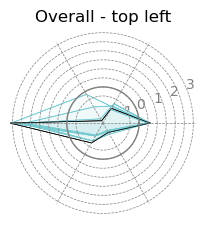

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_tic

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders_new/spider_overall_top_left.pdf
0.7448912297779967
-4 6.2860359346928325
[-1, 0, 1, 2, 3, 4, 5, 6]


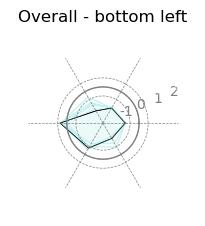

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders_new/spider_overall_bottom_left.pdf
1.1006365540227645
-4 6.2860359346928325
[-1, 0, 1, 2, 3, 4, 5, 6]


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_tic

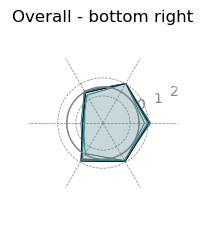

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders_new/spider_overall_bottom_right.pdf
1.8014297957158083
-4 6.2860359346928325
[-1, 0, 1, 2, 3, 4, 5, 6]


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_tic

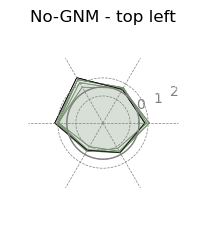

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders_new/spider_no_gnm_top_left.pdf
0.5415792012715159
-4 6.2860359346928325
[-1, 0, 1, 2, 3, 4, 5, 6]


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_tic

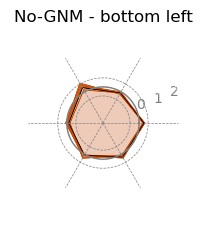

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders_new/spider_no_gnm_bottom_left.pdf
0.8365890605666814
-4 6.2860359346928325
[-1, 0, 1, 2, 3, 4, 5, 6]


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_tic

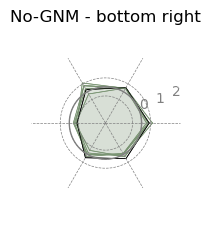

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders_new/spider_no_gnm_bottom_right.pdf
2.6967555935826018
-4 6.2860359346928325
[-1, 0, 1, 2, 3, 4, 5, 6]


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_tic

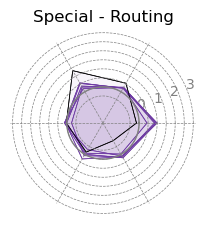

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders_new/spider_special_routing.pdf
0.9700120732899878
-4 6.2860359346928325
[-1, 0, 1, 2, 3, 4, 5, 6]


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_tic

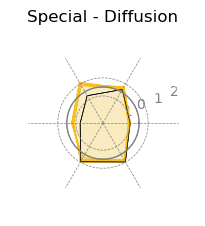

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders_new/spider_special_diffusion.pdf
2.718959103283739
-4 6.2860359346928325
[-1, 0, 1, 2, 3, 4, 5, 6]


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_tic

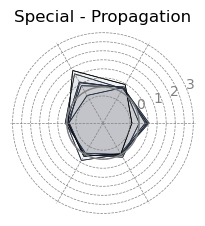

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders_new/spider_special_propagation.pdf
1.3445727948445458
-4 6.2860359346928325
[-1, 0, 1, 2, 3, 4, 5, 6]


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_tic

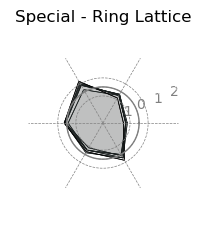

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders_new/spider_special_ring lattice.pdf
1.2561499431530647
-4 6.2860359346928325
[-1, 0, 1, 2, 3, 4, 5, 6]


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_tic

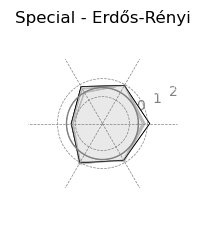

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders_new/spider_special_erdős-rényi.pdf
nan
-4 6.2860359346928325
[-1, 0, 1, 2, 3, 4, 5, 6]


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_ticklabels(labels=tick_labels,
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_67097/663536639.py:192: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.yaxis.set_tic

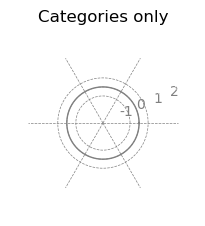

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders_new/spider_categories_only.pdf


In [ ]:
# FILLED 

# ── 2. Updated get_neighbours (unchanged logic, works with cat_scaled_all too) ─
from sklearn.metrics import pairwise_distances

def get_neighbours(orig_idx, embed, n=5, exclude_gnm=False, df_label=None, gnm_name=None):
    dists = pairwise_distances(embed[orig_idx:orig_idx + 1], embed)[0]
    dists[orig_idx] = np.inf
    if exclude_gnm and df_label is not None:
        dists[(df_label["dataset"] == gnm_name).values] = np.inf
    return np.argsort(dists)[:n].tolist()


# ── 3. Rebuild panels using category values ───────────────────────────────────

panels = []

for corner_name, orig_idx in corners_full.items():
    ds    = huge_df["dataset"].iloc[orig_idx]
    color = huge_df["color_dataset"].iloc[orig_idx] #### OR "black" OR COLOR_SCHEME[ds]
    nb_idx  = get_neighbours(orig_idx, pca_result, n=5)
    nb_vals = [cat_scaled_all[i] for i in nb_idx]      # ← cat-level rows
    panels.append((
        f"Overall - {corner_name.replace('_', ' ')}",
        cat_scaled_all[orig_idx], 
        color,                # ← cat-level row
        f"spider_overall_{corner_name}.pdf",
        nb_vals,
    ))

for corner_name, orig_idx in corners_no_gnm.items():
    ds    = huge_df["dataset"].iloc[orig_idx]
    color = COLOR_SCHEME[ds]
    nb_idx  = get_neighbours(orig_idx, pca_result, n=5,
                             exclude_gnm=True, df_label=huge_df, gnm_name="hcp_schaefer_100_dataset_gnm")
    nb_vals = [cat_scaled_all[i] for i in nb_idx]
    panels.append((
        f"No-GNM - {corner_name.replace('_', ' ')}",
        cat_scaled_all[orig_idx], color,
        f"spider_no_gnm_{corner_name}.pdf",
        nb_vals,
    ))

for ds_key, orig_idx in special_indices.items():
    label_text = LABEL_MAP[ds_key]
    color = COLOR_SCHEME[ds_key]
    nb_idx  = get_neighbours(orig_idx, pca_result, n=5)
    nb_vals = [cat_scaled_all[i] for i in nb_idx]
    panels.append((
        f"Special - {label_text}",
        cat_scaled_all[orig_idx], color,
        f"spider_special_{label_text.lower()}.pdf",
        nb_vals,
    ))
    
    
# One empty one - no neighbors either, just to show the axes with category labels and no data. But make it have all rings visible to show the full scale of category values (unlike the others which may have some rings cut off if their max value is low)
COLOR = "gray" # lightgray 
panels.append((
    "Categories only",
    np.full(len(cat_order_present), np.nan),
    COLOR,
    "spider_categories_only.pdf",
    None,
))

# ── 4. Render ─────────────────────────────────────────────────────────────────

all_corner_indices = (
    list(corners_full.values()) +
    list(corners_no_gnm.values()) +
    list(special_indices.values())
)
# all_vals = np.concatenate([scaled_data[idx, rep_idx] for idx in all_corner_indices])

# YLIM = (np.floor(all_vals.min()), np.ceil(all_vals.max()))
YLIM = [-1, 2] # 4] # 10]
RING_VALS = [-1, 0, 1, 2, 3, 4, 5, 6] # -6, 2] # 


def make_spider_standalone(values, label, color, feature_labels, title, ylim,
                           filepath, neighbour_vals_list=None,
                           axis_colors=None, ring_vals=None):
    n = len(values)
    angles        = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles_closed = angles + angles[:1]
    vals_closed   = list(values) + [values[0]]
    
    print(max(vals_closed))
    ring_color = "gray"
    if max(vals_closed) > 2: # 4:
        ring_colors = [ring_color] * len(RING_VALS) # 5
        tick_labels = RING_VALS # ["-1", "0", "1", "2", "4", "6"]
        y_max_change = 0 
    else: 
    # elif max(vals_closed) > 0: # 2:
        ring_colors = [ring_color] * 3 + ["white"] * (len(RING_VALS) - 3)
        tick_labels = ["-1", "0", "1", "2"] + [""] * (len(RING_VALS) - 4) # , "", ""]
        y_max_change = 2
    # else:
    #     ring_colors = [ring_color] * 2 + ["white"] * 2
    #     tick_labels = ["-2", "0", "", "", ""]
    #     y_max_change = 4

    fig, ax = plt.subplots(figsize=viz.cm_to_inch((6,6)), subplot_kw=dict(polar=True), dpi=100)
    ax.set_ylim(*ylim) # y_max)
    # ax.set_ylim(ylim[0], ylim[1]-y_max_change) # y_max)
    print(*ylim)
    ax.spines["polar"].set_visible(False)
    ax.yaxis.grid(False) 
    ax.xaxis.grid(False)

    theta_ring = np.linspace(0, 2 * np.pi, 300)

    # Neighbour lines
    alpha_fill = 0.05
    linewidth  = 0.5
    zorder     = 3

    ########################################################################################
    # ONCE FOR THE WHITE FILLING 
    ########################################################################################

    # Neighbors 
    if neighbour_vals_list is not None:
        for nb_vals in neighbour_vals_list:
            nb_closed = list(nb_vals) + [nb_vals[0]]
            ax.plot(angles_closed, nb_closed,
                    color=color, #  if not "Overall" in label else "black", 
                    linewidth=linewidth, 
                    alpha=1, # 0.25, 
                    zorder=zorder + 1)
            ax.fill(angles_closed, nb_closed,
                    color="white", alpha=1, 
                    zorder=zorder)


    # Main polygon
    ax.fill(angles_closed, vals_closed, color="white", alpha=1, zorder=zorder)
    ax.plot(angles_closed, vals_closed,
            color="black", # color if not "Overall" in label else "black", 
            linewidth=linewidth, 
            zorder=zorder + 1)


    ########################################################################################
    # ONCE FOR THE RINGS 
    ########################################################################################

    # Neighbour lines
    alpha_fill = 0.05
    linewidth  = 0.5
    zorder     = 3
    if neighbour_vals_list is not None:
        for nb_vals in neighbour_vals_list:
            nb_closed = list(nb_vals) + [nb_vals[0]]
            ax.plot(angles_closed, nb_closed,
                    color=color, #  if not "Overall" in label else "black", 
                    linewidth=linewidth, 
                    alpha=1, # 0.25, 
                    zorder=zorder + 1)
            ax.fill(angles_closed, nb_closed,
                    color=color, alpha=alpha_fill, zorder=zorder)


    # Main polygon
    ax.fill(angles_closed, vals_closed, color=color, alpha=alpha_fill, zorder=zorder)
    ax.plot(angles_closed, vals_closed,
            color="black", # color if not "Overall" in label else "black", 
            linewidth=linewidth, 
            zorder=zorder + 1)


    ########################################################################################


    # Remove labels 
    ax.set_thetagrids([])   

    # x ticks should be gray
    ax.tick_params(axis='y', labelcolor=axis_colors) # , labelsize=7)


    # Gridlines
    zorder_grid = 10 
    ring_vals = ring_vals if ring_vals is not None else RING_VALS
    print(ring_vals)
    for i, r_val in enumerate(ring_vals):   
        ax.plot(theta_ring, np.full(300, r_val),
                color=ring_colors[i], linewidth=0.5, # 0.6, 
                linestyle="--", zorder=zorder_grid)
        ax.yaxis.set_ticklabels(labels=tick_labels, 
                                fontdict={'verticalalignment': 'baseline',
                                'horizontalalignment': 'left'}) # center'}) # label_position("right")

    ax.plot(theta_ring, np.zeros(300),
            color=axis_colors, linewidth=1, # 1.8, 
            linestyle="-", zorder=zorder_grid)
    
    for angle in angles:
        ax.plot([angle, angle], [ylim[0], ylim[1]-y_max_change], # ylim,
                color=axis_colors, linewidth=0.5, # 0.5, 
                linestyle="--", zorder=zorder_grid)



    ax.set_title(title) # , pad=16, fontsize=9)
    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(filepath)
    
    

all_vals = np.nanmax([v for _, vals, *_ in panels for v in vals])
dyn_ylim     = (cat_ylim[0], 2 if all_vals <= 2 else 4 if all_vals <= 4 else cat_ylim[1])
# dyn_ring_vals = [r for r in RING_VALS if r <= dyn_ylim[1]]
dyn_ring_vals = RING_VALS
print(dyn_ring_vals)

output_folder = OUTPUT_FOLDER / "spiders_new"
output_folder.mkdir(exist_ok=True)

for title, vals, color, fname, nb_vals in panels:
    make_spider_standalone(
        values          = vals,
        label           = title,
        color           = color,
        feature_labels  = CATEGORY_ORDER, # cat_labels,        # ← category names
        title           = title,
        # ylim            = cat_ylim,
        ylim            = (-4, dyn_ylim[1]),
        ring_vals       = dyn_ring_vals,
        filepath        = output_folder / fname,
        neighbour_vals_list = nb_vals,
        axis_colors     = COLOR, # cat_axis_colors,   # ← per-category label colors
    )



(-4, 4)
[-1, 0, 1, 2, 3, 4, 5, 6]


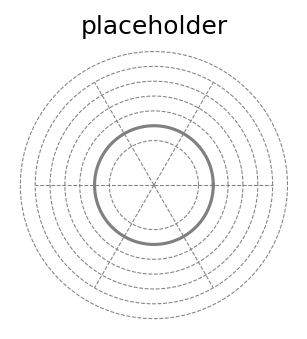

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders/spider_labels_only.pdf


In [ ]:

def make_legend_plot(feature_labels, angles, filepath, label_color=None):
    """Empty radar with only the spoke labels visible."""
    
    n = len(feature_labels)
    angles_plot = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()

    fig, ax = plt.subplots(figsize=viz.cm_to_inch((9,6)), subplot_kw=dict(polar=True), dpi=150)
    YLIM = (-4, 4) 
    print(YLIM)
    # fig, ax = plt.subplots(figsize=viz.cm_to_inch((12,12)), subplot_kw=dict(polar=True), dpi=150)
    ax.set_ylim(YLIM[0], YLIM[1]) # -3.5, 3.5
    ax.set_yticks([])
    ax.spines["polar"].set_visible(False)
    ax.yaxis.grid(False)
    ax.xaxis.grid(False)

    tick_labels = [-2,0,2]
    
    # Draw spoke lines
    for angle in angles_plot:
        ax.plot([angle, angle], YLIM, # [-3.5, 3.5],
                color=label_color, linewidth=0.5, # 1.8, # 2, # 0.5, 
                linestyle="--", zorder=0)
        
    # ── Group arcs just outside the outermost ring ──
    local_min, local_max = YLIM[0], YLIM[1]
    arc_r = local_max + (local_max - local_min) * 0.12
    # draw_axis_group_arcs(ax, list(feature_labels), angles, arc_r, AXIS_GROUPS)
    # Expand ylim slightly so the arc isn't clipped
    ax.set_ylim(local_min, arc_r + (local_max - local_min) * 0.05)

    # Zero ring
    theta_ring = np.linspace(0, 2 * np.pi, 300)
    ax.plot(theta_ring, np.zeros(300), color=label_color, # "gray", 
            # linewidth=1.8,
            zorder=1)
    # Other rings: 
    print(RING_VALS)
    for r_val in RING_VALS:  # YLIM: # [-2, 2]:
        theta_ring = np.linspace(0, 2 * np.pi, 300)
        ax.plot(theta_ring, np.full(300, r_val), color=label_color, linewidth=0.5, 
                linestyle="--", zorder=0)
        
        
        # ax.yaxis.set_ticklabels(labels=tick_labels, 
        #                         fontdict={'verticalalignment': 'baseline',
        #                         'horizontalalignment': 'left'}) # center'}) # label_position("right")


    # ── Category axis labels, colored per category ────────────────────────────

    # Replace " " in labels with newlines for better spacing
    feature_labels_to_print = [lbl.replace(" ", "\n") for lbl in feature_labels]
    font_colors = [CATEGORY_COLOURS[cat] for cat in feature_labels]
    
    # Add spoke labels manually
    for i, (angle, lbl) in enumerate(zip(angles_plot, feature_labels_to_print)):
        x = np.degrees(angle)
        ax.set_thetagrids(np.degrees(angles_plot), 
                          feature_labels_to_print,
                        #   fontweight="bold",
                        #   fontsize=8
                          )
        for idx, txt in enumerate(ax.get_xticklabels()):
            if txt.get_text() == lbl:
                txt.set_color(font_colors[i])
                # shift it a bit to the right (away from the spoke line)
                txt.set_horizontalalignment("left")
                txt.set_verticalalignment("center")
                
                if idx in [2,3,4]: 
                    txt.set_horizontalalignment("right")
                # txt.set_fontweight("bold")
                break



        # for i, (label_text, angle) in enumerate(zip(feature_labels_to_print, angles)):
        #     lbl_color = font_colors[i] if font_colors is not None else "black"
        #     # Find the Text object matplotlib just created and recolor it
            

        # ax.set_title("Legend / Labels", pad=16) # , fontsize=10, pad=16, fontweight="bold")
        
    # Remove labels 
    ax.set_thetagrids([])   

    # x ticks should be gray
    ax.tick_params(axis='y', labelcolor=COLOR) # , labelsize=7)

    plt.title("placeholder") 
    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(filepath)

angles_for_legend = np.linspace(0, 2 * np.pi, 6, # len(rep_labels), 
                                endpoint=False).tolist()

make_legend_plot(CATEGORY_ORDER, angles_for_legend, filepath=output_folder / "spider_labels_only.pdf", label_color=COLOR)

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders/pca_colored_by_ipc_ipc_deg1_mean.pdf


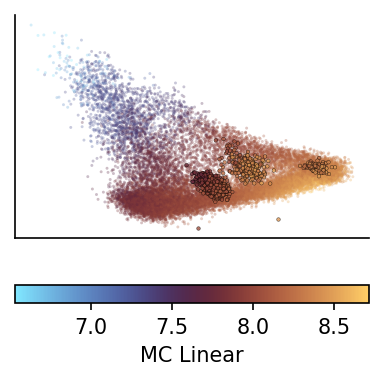

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders/pca_colored_by_ipc_ipc_deg2_mean.pdf


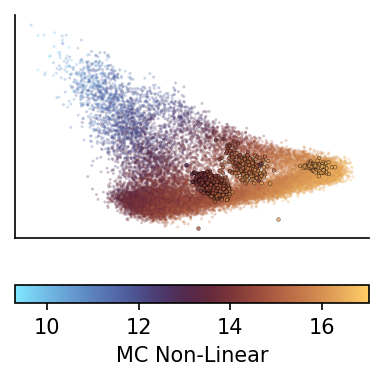

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders/pca_colored_by_mc_input_scaling_0_1_mc_mean.pdf


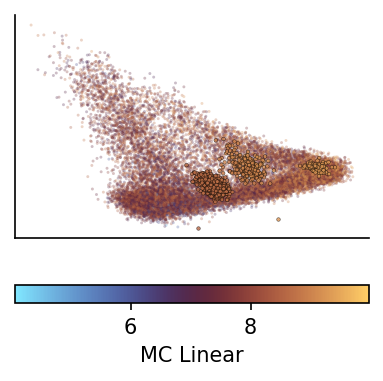

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders/pca_colored_by_mc_nonlinear_input_scaling_0_1_mc_mean.pdf


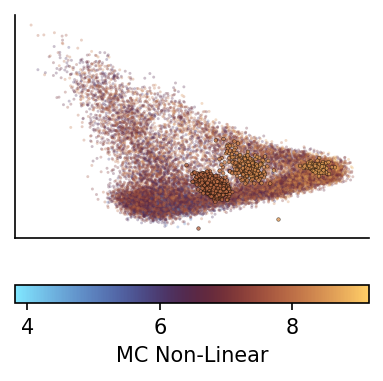

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders/pca_colored_by_spectral_radius.pdf


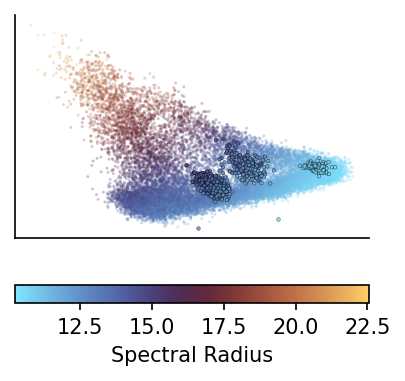

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders/pca_colored_by_avg_clustering.pdf


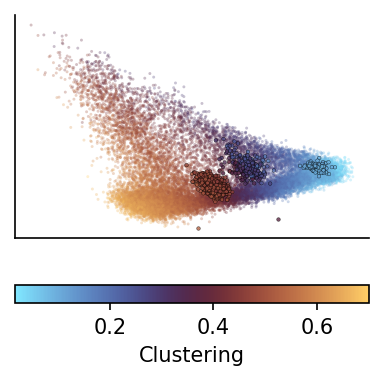

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders/pca_colored_by_spectral_radius.pdf


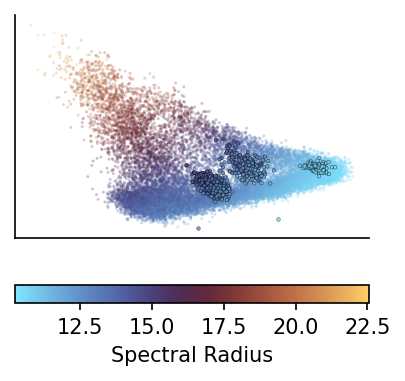

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders/pca_colored_by_targeted_attack_robustness_rob_targeted_auc.pdf


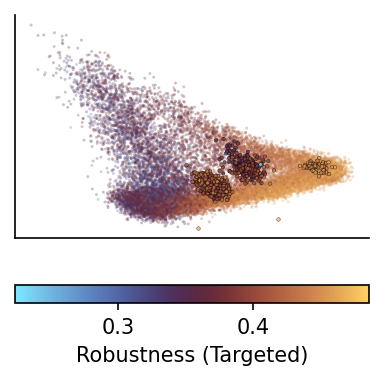

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders/pca_colored_by_global_efficiency.pdf


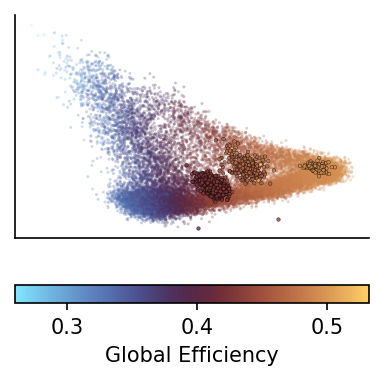

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders/pca_colored_by_modularity.pdf


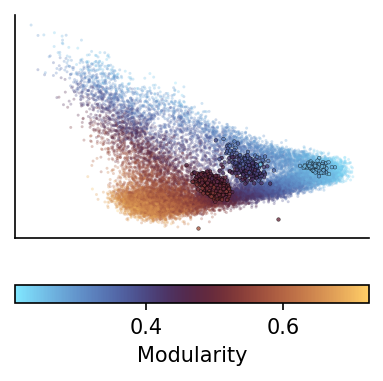

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders/pca_colored_by_proportion_long_range_connections_0.3956.pdf


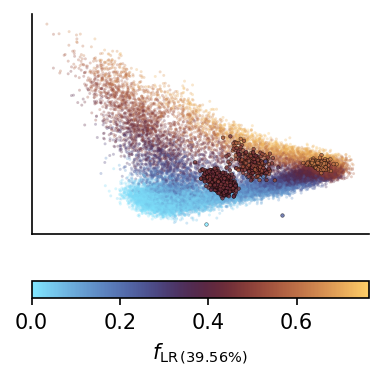

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders/pca_colored_by_targeted_attack_robustness_rob_targeted_auc.pdf


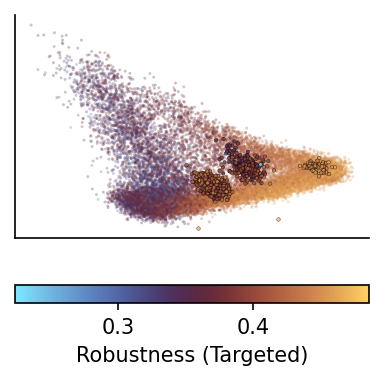

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders/pca_colored_by_algebraic_connectivity_fiedler_value.pdf


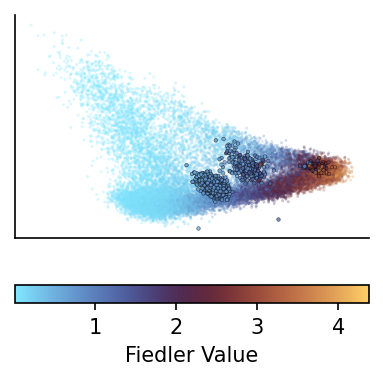

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders/pca_colored_by_spectral_radius.pdf


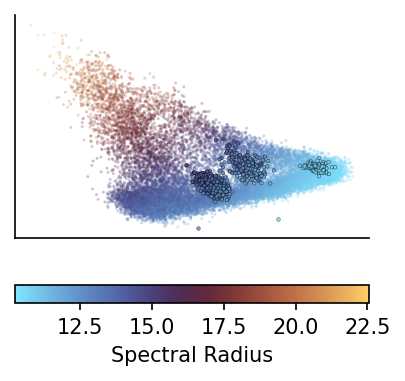

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders/pca_colored_by_repertoire_sweep_weighted_by_distances_diversity_critical.pdf


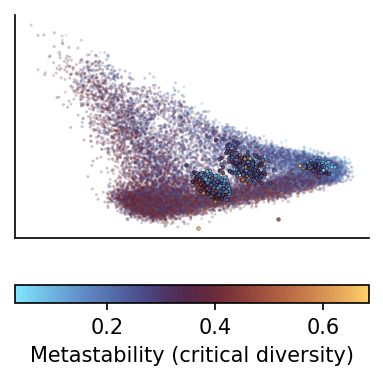

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders/pca_colored_by_local_efficiency_stats_mean.pdf


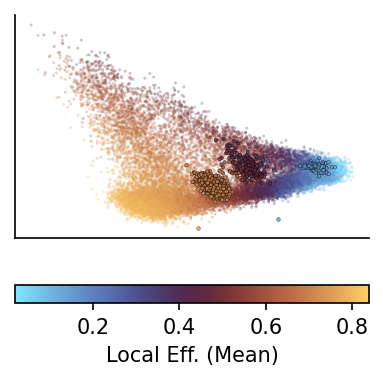

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders/pca_colored_by_betweenness_centrality_stats_mean.pdf


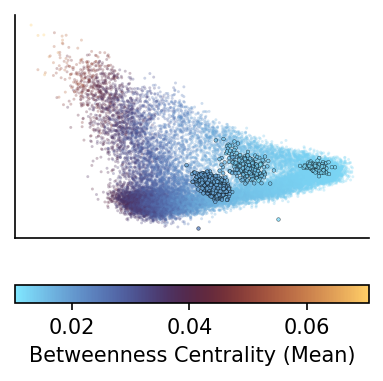

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders/pca_colored_by_gromov_hyperbolicity.pdf


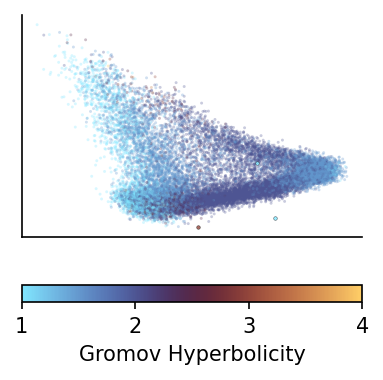

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders/pca_colored_by_synchronizability_eigenratio_eigenratio.pdf


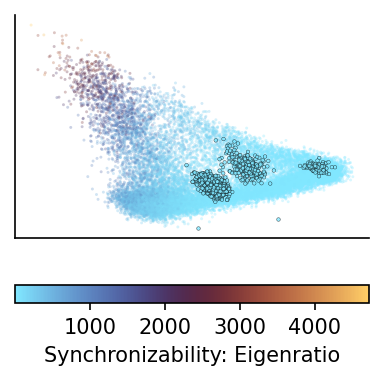

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis/spiders/pca_colored_by_targeted_attack_robustness_rob_random_auc.pdf


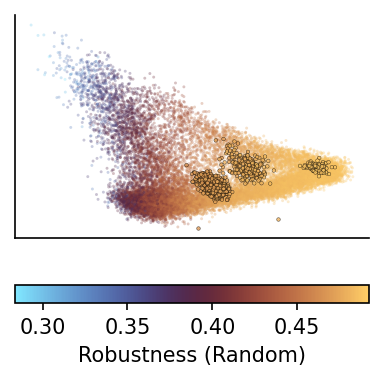

In [ ]:

measures_of_interest = [ # "mc_input_scaling_0_1_mc_mean",
                        # "mc_nonlinear_input_scaling_0_1_mc_mean", # "mc_mean", 
                        # "avg_clustering", "spectral_radius"] + 
                        # [
                        "ipc_ipc_deg1_mean", "ipc_ipc_deg2_mean", 
                        "mc_input_scaling_0_1_mc_mean", "mc_nonlinear_input_scaling_0_1_mc_mean", "spectral_radius", 
                        "avg_clustering", "spectral_radius", "targeted_attack_robustness_rob_targeted_auc",                 
                        "global_efficiency", "modularity", 
                        "proportion_long_range_connections_0.3956", "targeted_attack_robustness_rob_targeted_auc", 
                        "algebraic_connectivity_fiedler_value", "spectral_radius", 
                        # "computational_capacity_memory_capacity_total", "computational_capacity_nonlinear_capacity_total", 
                        "repertoire_sweep_weighted_by_distances_diversity_critical", 
                        "local_efficiency_stats_mean", "betweenness_centrality_stats_mean", "gromov_hyperbolicity", 
                        "synchronizability_eigenratio_eigenratio", "targeted_attack_robustness_rob_random_auc", 
                        
]
# ] + precise_categories 
cmap = plt.get_cmap("managua_r") # cividis") # berlin")

for thing_to_be_colored in measures_of_interest:

    fig, ax = plt.subplots(figsize=viz.cm_to_inch((6,6)), dpi=150)

    vmin, vmax = huge_df[thing_to_be_colored].min(), huge_df[thing_to_be_colored].max()
    norm = plt.Normalize(vmin, vmax)
    
    for ds in huge_df["dataset"].unique():
        mask = (huge_df["dataset"] == ds).values
        ax.scatter(
            pca_result[mask, 0], pca_result[mask, 1],
            # c=COLOR_SCHEME[ds], 
            # c=huge_df[mask]["color_dataset"], # COLOR_SCHEME[ds], 
            c=huge_df[mask][thing_to_be_colored], # color by the chosen metric instead of dataset
            cmap=cmap,
            label=LABEL_MAP.get(ds, ds),
            alpha=0.3 if "gnm" in ds else 0.8, 
            s=2 if "gnm" in ds else 3, 
            edgecolors="none" if "gnm" in ds else "black", 
            linewidths=0 if "gnm" in ds else 0.2,
            zorder=1,
            norm=norm
        )
        
    ax.spines[["top", "right"]].set_visible(False)
    # ax.set_xlabel("PC1") # , fontsize=10)
    # ax.set_ylabel("PC2") # , fontsize=10)
    ax.set_xticks([]) # Hide x-axis ticks for cleaner look
    ax.set_yticks([]) # Hide y-axis ticks for cleaner look
    # plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), 
    #              ax=ax, 
    #              label=SELECTED_PROPERTIES_NAMES[thing_to_be_colored] if thing_to_be_colored in SELECTED_PROPERTIES_NAMES else thing_to_be_colored,
    #             #  label=PROPERTY_NAMES[thing_to_be_colored], 
    #              orientation='horizontal')
    
    plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax, 
                 label=SELECTED_PROPERTIES_NAMES.get(thing_to_be_colored, thing_to_be_colored),
                 orientation='horizontal')
    
    # ax.set_title("PCA — All 9 Highlighted Points") # , fontsize=11, fontweight="bold")

    plt.tight_layout(pad=0.01)
    plt.savefig(output_folder / f"pca_colored_by_{thing_to_be_colored}.pdf", dpi=150) # , bbox_inches="tight")
    print(output_folder / f"pca_colored_by_{thing_to_be_colored}.pdf")
    plt.show()